# Understanding galaxy star formation rate estimates using radio luminosities

The star formation rate (SFR) of a galaxy is a fundamental property describing its current degree of activity and (together with its stellar mass) its current evolutionary state. There are, however, many different ways to estimate galaxy star formation rates, and all suffer from various limitations. Radio luminosity is potentially a unique tracer for this key property, presuming that any contribution from an active galactic nucleus (AGN) can be excluded, due to its direct link to the high-mass stellar population. In this project we will use data from EMU early science observations and the GAMA survey, in the G23 field. After excluding AGN systems through standard emission line diagnostics, we will explore a suite of common SFR estimators, and compare these against a selection of published radio SFR estimators, newly calculated for the EMU/GAMA data. We will also use the population synthesis tool, ProSpect, to provide independent SFR estimates (without relying on the radio data), as a step toward synthesising all available photometry in inferring SFRs. We will, finally, use ProSpect again to incorporate the radio measurements explicitly to derive refined SFRs, and use these directly to assess the reliabiility and robustness of any SFR estimates based on radio luminosity in isolation. A stretch goal for this project will be to link the SFRs and stellar masses for this sample to explore the “galaxy main sequence” of SFR as a function of stellar mass, and how it evolves over the redshift range spanned by the GAMA measurements.

## <span style='background :LightPink' > Load in Packages

In [1]:
from astropy.io import fits
from astropy.table import Table
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from astropy import units as u
import cosmopy
import math
import seaborn as sns
from statistics import mean

import astropy.cosmology.units as cu
from astropy.cosmology import WMAP9 
from scipy.optimize import curve_fit
from scipy.stats import norm 

import warnings
import matplotlib.patches as mpatches

In [2]:
import matplotlib.colors as colors
from matplotlib import path
try:
    from astropy.convolution import Gaussian2DKernel, convolve
    astro_smooth = True
except ImportError as IE:
    astro_smooth = False

### <span style='background :LightPink' > Install packages

In [3]:
pip install cosmopy

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


## <span style='background :LightPink' > Load in Data

In [11]:
#cd /Volumes/G/Project_AHopkins/Data  #MAC
#cd \Project_AHopkins\Data    #WINDOWS

In [10]:
cd \Project_AHopkins\Data

G:\Project_AHopkins\Data


### <span style='background :LightPink' > EMU Data

In [22]:
#Load in EMU data

EMU_G23=fits.open('G23-ASKAP-EMUES-master-cat.fits')
#EMU_G23.info()
EMU_data=Table(EMU_G23[1].data)
#EMU_data

### <span style='background :LightPink' > GAMA

In [19]:
#Load each GAMA catalog

GFit=fits.open('GaussFitSimplev05.fits') #try complex
gkv=fits.open('gkvScienceCatv02.fits')
SMasses=fits.open('StellarMassesGKVv24.fits')

In [20]:
# GFit.info()
# gkv.info()
# SMasses.info()

In [24]:
#Change datasets to pandas dataframe
GFit_data=Table(GFit[1].data)
#GFit_data
gkv_data=Table(gkv[1].data)
#gkv_data
SMasses_data=Table(SMasses[1].data)
#SMasses_data

SMasses_pd=SMasses_data.to_pandas()
gkv_pd=gkv_data.to_pandas()
GFit_pd=GFit_data.to_pandas()
EMU_pd=EMU_data.to_pandas()

#SMasses_pd

### <span style='background :LightPink' > Load Crossmatched data 

In [25]:
#Load in the cross match of all 5 (Emu, three GAMA, Prospect Dust) catalogues

EMU_GAMA=fits.open('G:\Project_AHopkins\Data\EMU_GAMA_DUST_20240927', ignore_missing_simple=True)  #WINDOWS
#EMU_GAMA=fits.open('EMU_GAMA_DUST_20240927', ignore_missing_simple=True)   #MAC
EMU_GAMA=Table(EMU_GAMA[1].data)
EMU_GAMA_pd=EMU_GAMA.to_pandas()
EMU_GAMA_pd

,uberID_1,RAcen,Deccen,RAmax,Decmax,RAGAIA,DecGAIA,sky_mean,skyRMS_mean,log10seeing,...,Zgas_16,Zgas_84,DustMass_bestfit,DustMass_50,DustMass_16,DustMass_84,DustLum_50,DustLum_16,DustLum_84,uberID
0,337660015307322,339.086079,-33.992006,339.086200,-33.991969,339.086232,-33.992007,-2.350093e-13,3.636241e-12,-0.229771,...,-1.750702,-1.471971,1.993058e+08,2.101867e+08,1.534745e+08,2.592441e+08,2.800991e+10,2.412348e+10,3.635747e+10,338661071907331
1,337660028110052,339.069638,-33.734939,339.069633,-33.734997,339.069664,-33.735034,1.087712e-13,3.561583e-12,-0.229771,...,-2.081363,-1.543478,9.389003e+08,1.172964e+09,6.923591e+08,1.577425e+09,2.468965e+11,1.942337e+11,3.819114e+11,338661087910059
2,337660063707461,339.031074,-33.979172,339.031139,-33.979174,339.031170,-33.979211,1.175222e-13,3.746317e-12,-0.229771,...,-1.730675,-1.300000,1.216326e+08,1.366423e+08,7.033252e+07,2.299405e+08,7.406338e+10,6.151544e+10,9.070058e+10,338661120507464
3,337660064109616,339.029201,-33.776226,339.029178,-33.776263,339.029209,-33.776300,-1.543749e-12,4.281982e-12,-0.229771,...,-1.961143,-1.437897,1.134774e+07,2.474820e+07,3.301156e+06,1.777813e+08,4.890049e+10,3.430423e+10,1.092692e+11,338661123409619
4,337660067503966,339.029336,-34.308037,339.029268,-34.308288,339.029299,-34.308325,-3.846790e-13,3.952537e-12,-0.229771,...,-1.686146,-1.454063,3.096605e+08,2.949962e+08,2.230230e+08,3.734846e+08,6.675478e+10,6.104367e+10,7.402255e+10,338661120203968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5719,350701003108055,350.382758,-30.024162,350.382800,-30.024193,350.382831,-30.024230,-5.009163e-13,3.821218e-12,-0.184533,...,-1.972705,-1.528802,3.100192e+08,2.870679e+08,1.422809e+08,4.208902e+08,4.281858e+10,3.506062e+10,6.223780e+10,350701003108055
5720,350701026307521,350.357272,-30.074469,350.357343,-30.074394,350.357375,-30.074431,-1.064117e-13,4.214858e-12,-0.184533,...,-1.793917,-1.401841,5.518692e+06,7.674942e+05,1.261835e+05,8.542194e+06,7.826745e+09,6.360885e+09,9.456894e+09,350701026307521
5721,350701028002930,350.353571,-30.506697,350.353535,-30.506690,350.353567,-30.506728,-3.367662e-12,4.571152e-12,-0.184533,...,-1.643478,-1.393963,9.341521e+07,1.025608e+08,7.437009e+07,1.323103e+08,1.534669e+10,1.312530e+10,1.754873e+10,350701028002930
5722,350701040104571,350.340938,-30.352201,350.341034,-30.352125,350.341065,-30.352162,-3.784270e-13,4.242341e-12,-0.184533,...,-1.637408,-1.386055,2.241911e+08,2.136106e+08,1.604303e+08,2.606047e+08,4.417676e+10,3.571403e+10,5.030358e+10,350701040104571


## <span style='background :LightPink' > Data Reduction

In [26]:
#Quality Cuts Done here:

EMU_GAMA_pd=EMU_GAMA_pd[EMU_GAMA_pd.HA_FLUX >0]
EMU_GAMA_pd=EMU_GAMA_pd[EMU_GAMA_pd.HB_FLUX >0]


#Signal to noise
EMU_GAMA_pd=EMU_GAMA_pd[(EMU_GAMA_pd.HA_FLUX/EMU_GAMA_pd.HA_FLUX_ERR) >3]
EMU_GAMA_pd=EMU_GAMA_pd[(EMU_GAMA_pd.HB_FLUX/EMU_GAMA_pd.HB_FLUX_ERR) >3]

#Quality number
EMU_GAMA_pd=EMU_GAMA_pd[EMU_GAMA_pd['NQ_1']>=3]


EMU_GAMA_pd=EMU_GAMA_pd[EMU_GAMA_pd['HA_EW']>0]
EMU_GAMA_pd=EMU_GAMA_pd[EMU_GAMA_pd['HB_EW']>0]


EMU_GAMA_pd=EMU_GAMA_pd[EMU_GAMA_pd['HA_FLUX']<100000]
EMU_GAMA_pd=EMU_GAMA_pd[EMU_GAMA_pd['HB_FLUX']<100000]


In [27]:
#EMU_GAMA=Table.from_pandas(EMU_GAMA_pd)
#EMU_GAMA.write('EMU_GAMA_reduced_20240927.fits')

## <span style='background :LightPink' > BPT Diagnostics

add kewley and kauffmann lines 

kauffmann log(OIII/HB) = 1.3 + 0.61/(log(NII/HA)-0.05)

kewely log(OIII/HB) = (0.61/(log(NII/HA) -0.47))+ 1.19 

In [29]:
#Define Flux variables for easy calling
HB=EMU_GAMA_pd['HB_FLUX']
HA=EMU_GAMA_pd['HA_FLUX']
NII=EMU_GAMA_pd['NIIR_FLUX']
OIII=EMU_GAMA_pd['OIIIR_FLUX']

x=np.log10(NII/HA)
y=np.log10(OIII/HB)

x=np.array(x)

In [30]:
#Define ratios
EMU_GAMA_pd.insert(2, "log(NII/Ha)", x[:])
EMU_GAMA_pd.insert(3, "log(OIII/HB)", y[:])

In [32]:
#Define Kauffmann and Kewely lines
x1=np.log10(np.arange(-50, 1, 0.01))
x2=np.log10(np.arange(-50, 2.5, 0.01))
y1=1.3 + 0.61/(x1-0.05) #kauffmann
y2=(0.61/(x2 -0.47))+1.19  #kewely

C:\Users\Jayde\AppData\Local\Temp\ipykernel_26676\1184415537.py:2: RuntimeWarning: invalid value encountered in log10
  x1=np.log10(np.arange(-50, 1, 0.01))
C:\Users\Jayde\AppData\Local\Temp\ipykernel_26676\1184415537.py:3: RuntimeWarning: invalid value encountered in log10
  x2=np.log10(np.arange(-50, 2.5, 0.01))


In [33]:
#Define contour map
H, xedges, yedges = np.histogram2d(EMU_GAMA_pd['log(NII/Ha)'],EMU_GAMA_pd['log(OIII/HB)'],range=[[-1.3,1.3],[-1.5,1.1]], bins=60)
xmesh, ymesh = np.meshgrid(xedges[:-1], yedges[:-1])
if astro_smooth:
    kernel = Gaussian2DKernel(x_stddev=1)
    H=convolve(H,kernel)


Text(0, 0.5, 'log([OIII] $\\lambda$ 5007/H$\\beta$)')

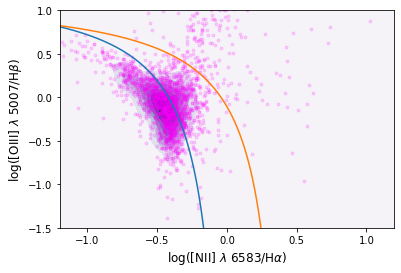

In [35]:
#Initial BPT Plot
Nsize=12
fig, ax = plt.subplots()
clevels = ax.contourf(xmesh,ymesh,H.T, cmap='Purples')
plt.scatter(EMU_GAMA_pd['log(NII/Ha)'],EMU_GAMA_pd['log(OIII/HB)'], marker=".", color='magenta', alpha=0.15)
plt.plot(x1,y1, label='Kaufmann')
plt.plot(x2, y2)
ax.set_xlim(-1.2,1.2)
ax.set_ylim(-1.5,1)
ax.set_xlabel(r'log([NII] $\lambda$ 6583/H$\alpha$)',fontsize=Nsize)
ax.set_ylabel(r'log([OIII] $\lambda$ 5007/H$\beta$)',fontsize=Nsize)

### <span style='background :LightPink' > Creating Sample1

In [266]:
sample1=EMU_GAMA_pd[EMU_GAMA_pd['log(OIII/HB)']<1.3 + 0.61/(EMU_GAMA_pd['log(NII/Ha)']-0.05)]
#sample1

In [267]:
sample1=sample1[sample1['log(NII/Ha)']<0]

In [268]:
#sample1
#plt.scatter(sample1['log(NII/Ha)'], sample1['log(OIII/HB)'])

In [269]:
#from astropy.table import Table
t=Table.from_pandas(sample1)
#t.write('G:\\Project_AHopkins\Data\sample1_27092024.csv')

### <span style='background :LightPink' > Creating Sample2

In [270]:
sample2=EMU_GAMA_pd[EMU_GAMA_pd['log(OIII/HB)']>1.3 + 0.61/(EMU_GAMA_pd['log(NII/Ha)']-0.05)]

In [271]:
sample2=sample2[sample2['log(OIII/HB)']<1.19 + 0.61/(sample2['log(NII/Ha)']-0.47)]
#sample2

In [272]:
samp2=Table.from_pandas(sample2)
#samp2.write('G:\\Project_AHopkins\Data\sample2_27092024.csv', overwrite=True)

### <span style='background :LightPink' > Creating Sample3

In [273]:
mask1= (EMU_GAMA_pd['log(OIII/HB)']>1.19 + 0.61/(EMU_GAMA_pd['log(NII/Ha)']-0.47))
mask2= (EMU_GAMA_pd['log(NII/Ha)']>0.1)

In [274]:
sample3=EMU_GAMA_pd[mask1 | mask2]
#sample3

In [275]:
samp3=Table.from_pandas(sample3)
#samp3.write('G:\\Project_AHopkins\Data\sample3_27092024.csv', overwrite=True)

### <span style='background :LightPink' > Return to BPT

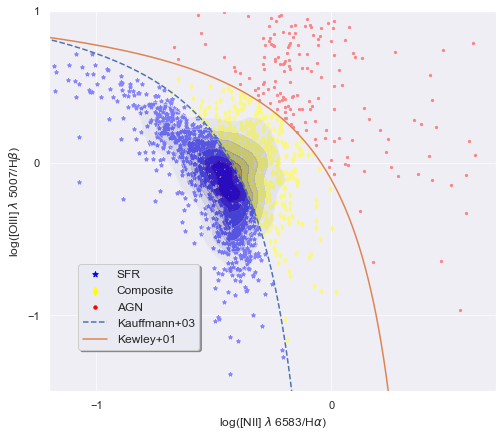

In [276]:
#Nicer BPT
fig, ax = plt.subplots(figsize=(8,7))

plt.scatter(sample1['log(NII/Ha)'], sample1['log(OIII/HB)'], color='blue', marker='*', sizes=[15], label='SFR')
plt.scatter(sample2['log(NII/Ha)'], sample2['log(OIII/HB)'], color='yellow',marker='d', sizes=[15], label='Composite')
plt.scatter(sample3['log(NII/Ha)'], sample3['log(OIII/HB)'], color='red', marker='.',sizes=[20], label='AGN')


#plt.scatter(EMU_GAMA_pd['log(NII/Ha)'],EMU_GAMA_pd['log(OIII/HB)'], marker=".", color='black')
clevels = ax.contourf(xmesh,ymesh,H.T, cmap='Purples',alpha=0.55)

plt.plot(x1,y1, linestyle='dashed', label='Kauffmann+03')
plt.plot(x2, y2, label='Kewley+01' )
ax.set_xlim(-1.2,0.7)
ax.set_ylim(-1.5,1)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
ax.legend(loc='upper right', bbox_to_anchor=(0.35, 0.35), fontsize=12, markerscale=1.5, shadow=True)
ax.set_xlabel(r'log([NII] $\lambda$ 6583/H$\alpha$)',fontsize=12)
ax.set_ylabel(r'log([OIII] $\lambda$ 5007/H$\beta$)',fontsize=12)
#plt.scatter(kaufmann_points[0],kaufmann_points[1], marker="*", alpha=0.3)
plt.savefig('E:\\BPT.png')

## <span style='background :LightPink' > Radio Flux to SFR

## <span style='background :LightPink' >  Calculate Distances

In [277]:
#redshift from sample
z_1=np.array(sample1['Z_1'])

In [278]:
#cosmopy distances
print(cosmopy.api('z', z_1[0]))

{'z': '0.1656', 'a': '0.8579', 'dc': '689.5620 Mpc', 'dl': '803.7397 Mpc', 'da': '591.6042 Mpc', 'arc': '2868.1779 pc', 'tl': '2.0832 Gyr', 'ta': '11.6695 Gyr', 'dm': '39.5256'}


In [279]:
#comoving method
DistLum=(1+sample1['Z_1'])*(sample1['comovingdist']) #
#Mpc to m
DistLum=DistLum*3.08567758128E+22
#DistLum

In [280]:
sample1.insert(2, "Luminosity_Distance", DistLum[:])
Dl=np.array(sample1['Luminosity_Distance'])

## <span style='background :LightPink' > Radio Luminosity


<div>
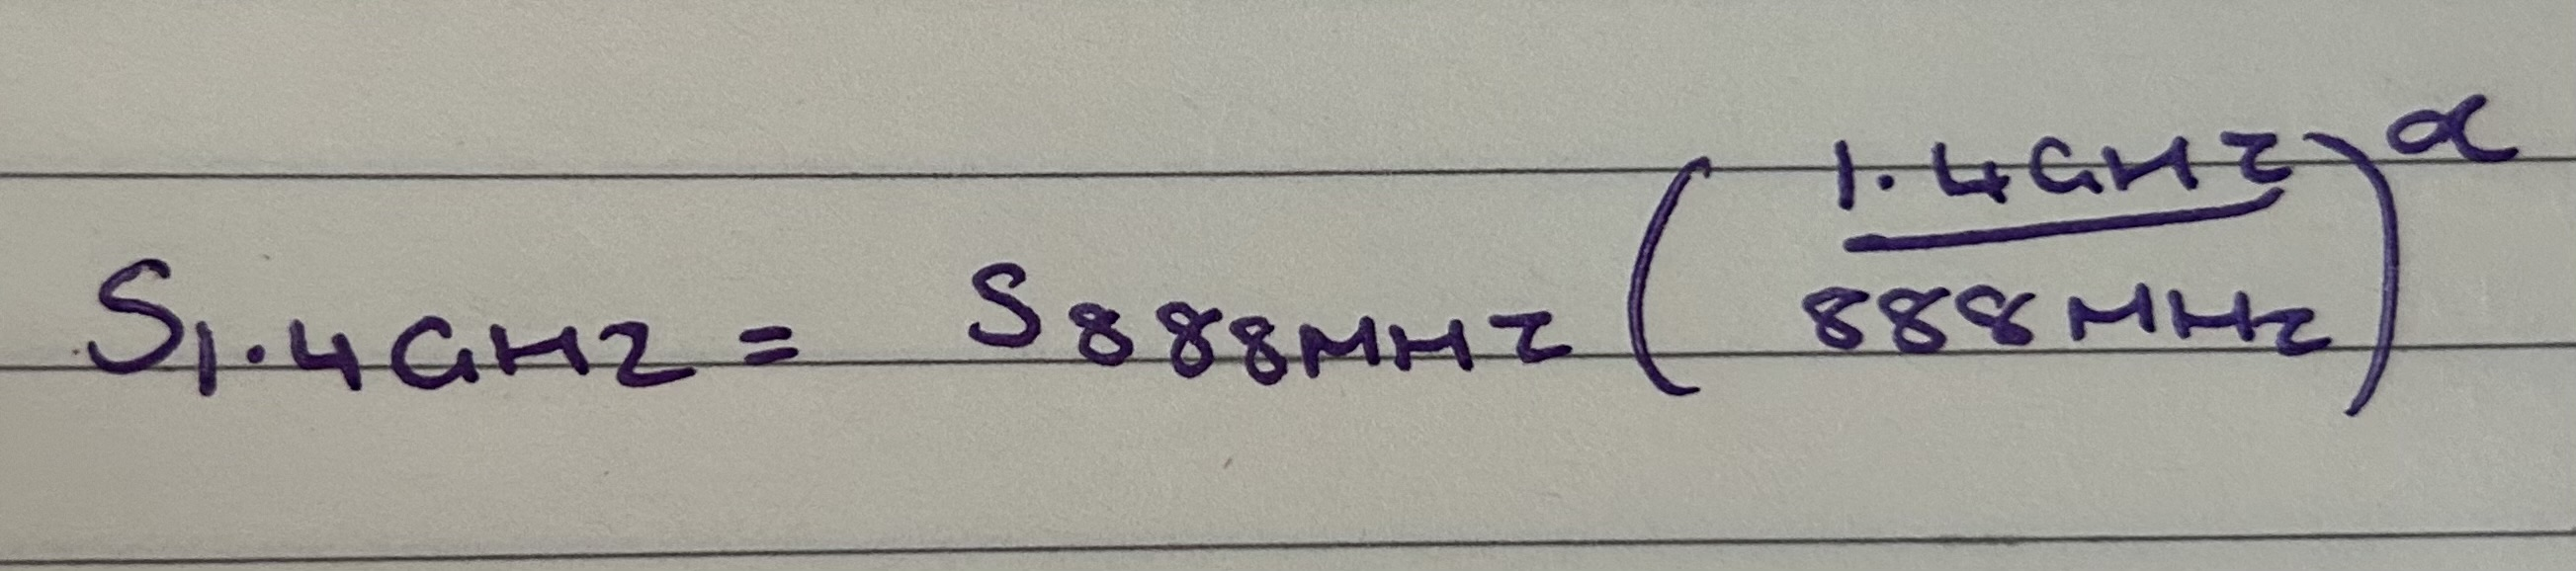
</div>



<div>
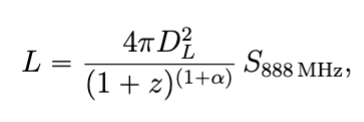
</div>

In [281]:
i=0
alpha=-0.7
flux14=np.array((sample1['Total_flux']*((1400/888)**alpha))*(10**(-26))) # 888 to 1.4 + Janksy flux to W/Hz
Dl2=[]
RadioLum14=[]

while i<1163:
 Dl2.append(float(Dl[i]**2))
 RadioLum14.append(((4*math.pi*Dl2[i])*flux14[i])/((1+z_1[i])**(1+alpha)))
 i=i+1

sample1.insert(2, "Radio_luminosity_14", RadioLum14[:])

In [282]:
sample1=sample1[sample1['Radio_luminosity_14']<9e24]

## <span style='background :LightPink' >  Radio Lum to SFR

## <span style='background :LightPink' > Bell 2003

Below is the version from A Hopkins 2003 10.1086/379608

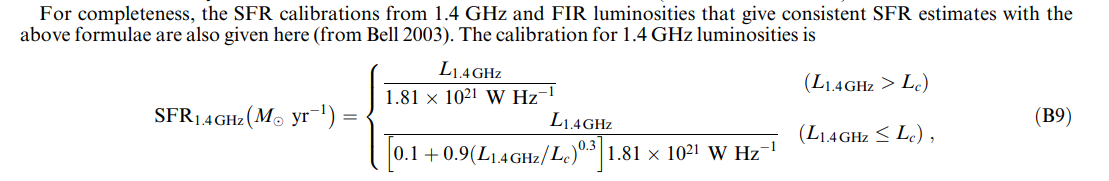


In [283]:
#Calculating Bell SFRs
i=0
Bell_SFR=[]
for x in sample1['Radio_luminosity_14']:
    if x>(6.4e21):
        Bell_SFR.append((1/(1.81e21))*x)
    else: 
        Bell_SFR.append((x)/(1.81e21*(0.1+0.9*((x/(6.4e21))**0.3))))
    i=i+1

In [284]:
sample1.insert(2, "Bell_SFR", Bell_SFR[:])

## <span style='background :LightPink' > Condon 1992

$$ SFR(M\ge 5M_☉) = \frac{5.3\times 10^{-21}  L_{1.4GHz}}{(1.4)^{0.7}} $$


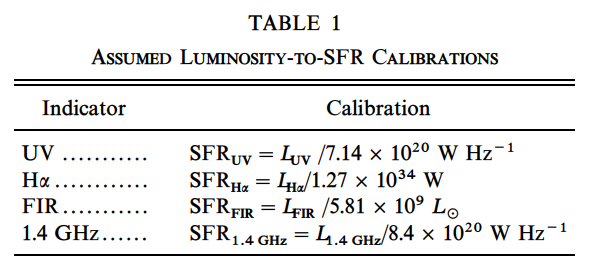


In [285]:
#below A 2001 condon with calibration
Condon_SFR=(sample1['Radio_luminosity_14']/(8.4e20))

In [286]:
sample1.insert(2, "Condon_SFR", Condon_SFR[:])
#Condon_SFR

## <span style='background :LightPink' > Hα Flux to SFR

### <span style='background :LightPink' > Calculate L$_{H\alpha}$

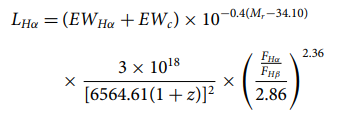


In [287]:
# Ha=sample1['HA_FLUX']
# Hb=sample1['HB_FLUX']


#units in e-17 erg/s/cm^2 so we need to multiply by e-17 and also change units to W/Hz with 1e7
#From Tanias: 10^-17 erg/s/cm^2/A to W/m^2/Hz Radio_G23['HB_FLUX_2'] = (Radio_G23['HB_FLUX_2']) * (10**(-17))
#Ha=sample1['HA_FLUX']*(1e-17)*(1e7)
#Hb=sample1['HB_FLUX']*(1e-17)*(1e7)


Ha=sample1['HA_FLUX']*(1e-17)*(1e-3)
Hb=sample1['HB_FLUX']*(1e-17)*(1e-3)


In [288]:
EW_Ha=sample1['HA_EW']  #Angstroms
EW_HB=sample1['HB_EW']  #Angstroms
EW_c= 2.5  #˚A from Hopkins(2003)  #EWc is the equivalent width correction for stellar absorption #Tania uses 2.5 from AHopkins 2013
Mr=sample1['absmag_r']
z=sample1['Z_1']

In [289]:
#correcting EW for balmer decrement
SHa=(EW_Ha+EW_c)*(Ha/EW_Ha)*(1e-17)
SHB=(EW_HB+EW_c)*(Hb/EW_HB)*(1e-17)
BD=SHa/SHB


In [290]:
Lum_HA=(EW_Ha + EW_c)*(10**(-0.4*(Mr-34.10)))*((3e18)/(6564.61*(1+z))**2)*((BD/2.86)**2.36)
Lum_HA_uncorr=(EW_Ha + EW_c)*(10**(-0.4*(Mr-34.10)))*((3e18)/(6564.61*(1+z))**2)

In [291]:
Lum_HA=np.array(Lum_HA)
Lum_HA

array([2.0512460e+35, 2.7142697e+35, 3.4188580e+35, ..., 1.1627572e+34,
       1.3947710e+35, 1.1535415e+34], dtype=float32)

In [292]:
sample1.insert(2, "HA_Luminosity", Lum_HA[:])

## <span style='background :LightPink' > Ahmed 2024 - Really Kennicut 1998

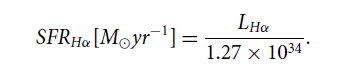
From Tanias^^ THIS IS REALLY KENNICUT 1998

In [293]:
#this is using the balmer decrement correct Ha luminosities
SFR_HA_Tan=1.27e-34*Lum_HA
SFR_HA_Tan

array([26.050823 , 34.471226 , 43.419495 , ...,  1.4767016, 17.71359  ,
        1.4649976], dtype=float32)

In [294]:
sample1.insert(2, "Ha_SFR", SFR_HA_Tan[:])

## <span style='background :LightPink' > Radio + Ha to SFR 

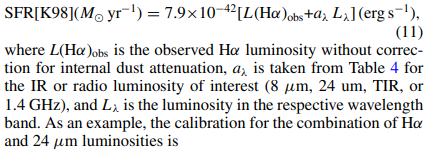

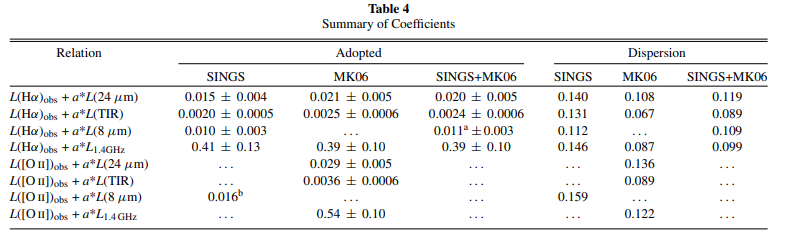

From 2009 paper

In [295]:
#This should be without the balmer decrement fro HA
K09_SFR=(7.9e-35)*((Lum_HA_uncorr)+(0.39*sample1['Radio_luminosity_14']))

In [296]:
sample1.insert(2, "K09_SFR", K09_SFR[:])


## <span style='background :LightPink' > Ha + Dust Mass SFR (Ahmed 2024) </span>

In [297]:
#the following method is defined through Ahmed2024
Dust_Mass=sample1['DustMass_bestfit']
#Dust_Mass

### <span style='background :LightPink' > Calculate $\tau$

$\tau^l_B = 2.303\log(\frac{\text{H}\alpha}{\text{H}\beta}) - 1.0578$

In [298]:
tau=(2.303*np.log10(Ha/Hb))-1.0578
#tau

In [299]:
#This is an alternate way of defining tau
tau2=np.log((Ha/Hb)/2.86)
#tau2

### <span style='background :LightPink' > Calculate H$_{dust}$

$H_{\rm dust} = \frac{M_d}{10^{\tau^l_B}}$

In [300]:
H_dust=Dust_Mass/(10**tau2)
#H_dust

In [301]:
#this is the alternate way of defining Hdust
H_dust2=(10**1.0578)*(Dust_Mass/((Ha/Hb)**2.303))
#H_dust2

### <span style='background :LightPink' > Calculate L$_{H\alpha,improved}$

In [302]:
L_Ha_impr=(10**(((np.log10(H_dust2)-22.564)/(1.165))+np.log10(Lum_HA)))
#L_Ha_impr

### <span style='background :LightPink' > Calculate SFR

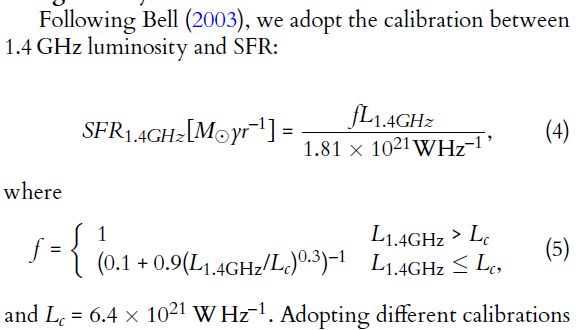

In [303]:
#We now use bell with corrected vals!
i=0
Dust_SFR=[] #variable called dust sfr refers to Ahmed 2024 and also called LHa_impr 
for x in L_Ha_impr:
    if x>(6.4e21):
        Dust_SFR.append((1/(1.81e21))*x)
    else: 
        Dust_SFR.append(((x)/(1.81e21))*((0.1+(0.9*((x/(6.4e21))**0.3)))**(-1)))
    i=i+1

In [304]:
sample1.insert(2, "Ha_impr_SFR", Dust_SFR[:])

### <span style='background :LightPink' >Final Cuts

In [305]:
sample1=sample1[sample1['HA_Luminosity']>2e-13]
sample1

,uberID_1,RAcen,Ha_impr_SFR,K09_SFR,Ha_SFR,HA_Luminosity,Condon_SFR,Bell_SFR,Radio_luminosity_14,Luminosity_Distance,...,Zgas_16,Zgas_84,DustMass_bestfit,DustMass_50,DustMass_16,DustMass_84,DustLum_50,DustLum_16,DustLum_84,uberID
0,337660015307322,339.086079,11.651385,3.002268,26.050823,2.051246e+35,35.317130,16.390270,2.966639e+22,2.437574e+25,...,-1.750702,-1.471971,1.993058e+08,2.101867e+08,1.534745e+08,2.592441e+08,2.800991e+10,2.412348e+10,3.635747e+10,338661071907331
2,337660063707461,339.031074,16.642817,6.827026,34.471226,2.714270e+35,65.070910,30.198654,5.465956e+22,4.364870e+25,...,-1.730675,-1.300000,1.216326e+08,1.366423e+08,7.033252e+07,2.299405e+08,7.406338e+10,6.151544e+10,9.070058e+10,338661120507464
3,337660064109616,339.029201,1.272349,3.697689,43.419495,3.418858e+35,68.922495,31.986130,5.789490e+22,4.908716e+25,...,-1.961143,-1.437897,1.134774e+07,2.474820e+07,3.301156e+06,1.777813e+08,4.890049e+10,3.430423e+10,1.092692e+11,338661123409619
4,337660067503966,339.029336,5.958650,1.792221,31.314770,2.465730e+35,37.077114,17.207058,3.114478e+22,3.122897e+25,...,-1.686146,-1.454063,3.096605e+08,2.949962e+08,2.230230e+08,3.734846e+08,6.675478e+10,6.104367e+10,7.402255e+10,338661120203968
10,337670054901341,339.238103,2.994095,1.931737,16.299454,1.283422e+35,7.405838,3.463392,6.220904e+21,9.330087e+24,...,-2.024387,-1.769998,7.329348e+07,8.584997e+07,6.577192e+07,1.049765e+08,1.356369e+10,1.266812e+10,1.485027e+10,337670054901341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5714,350700902306866,350.492093,0.876827,2.127400,21.695238,1.708287e+35,10.491048,4.868773,8.812480e+21,1.153000e+25,...,-1.517454,-1.300000,6.286991e+07,3.864522e+07,1.809681e+07,8.193255e+07,2.193433e+10,1.652379e+10,3.027521e+10,350700902306866
5719,350701003108055,350.382758,10.588110,2.648486,17.048174,1.342376e+35,26.136334,12.129569,2.195452e+22,3.118458e+25,...,-1.972705,-1.528802,3.100192e+08,2.870679e+08,1.422809e+08,4.208902e+08,4.281858e+10,3.506062e+10,6.223780e+10,350701003108055
5720,350701026307521,350.357272,0.155855,0.583758,1.476702,1.162757e+34,154.779026,71.831150,1.300144e+23,1.900297e+25,...,-1.793917,-1.401841,5.518692e+06,7.674942e+05,1.261835e+05,8.542194e+06,7.826745e+09,6.360885e+09,9.456894e+09,350701026307521
5722,350701040104571,350.340938,7.897896,2.694417,17.713591,1.394771e+35,25.968261,12.051569,2.181334e+22,1.937488e+25,...,-1.637408,-1.386055,2.241911e+08,2.136106e+08,1.604303e+08,2.606047e+08,4.417676e+10,3.571403e+10,5.030358e+10,350701040104571


In [306]:
t=Table.from_pandas(sample1)
#t.write('G:\\Project_AHopkins\Data\sample1_final.fits', overwrite=True)

## <span style='background :LightPink' >  Import Prospect Data

In [307]:
Prospect_Data=fits.open('G:\Project_AHopkins\Data\EMU_GAMA_DUST_SED_20241008', ignore_missing_simple=True)  #WINDOWS
#Prospect_Data=fits.open('EMU_GAMA_DUST_SED_20241008', ignore_missing_simple=True)   #MAC
Prospect_Data=Table(Prospect_Data[1].data)
Prospect_Data_pd=Prospect_Data.to_pandas()
#Prospect_Data_pd

In [308]:
#Sort each set of SED params based on whether they used radio or not. 
#The data is such that an radio then non radio pair will appear one after another so we can sort by indices.

Prospect_NoRadio=Prospect_Data_pd.iloc[1::2]


In [309]:
#IMPORT NEW PROSPECT RADIO DATA
Prospect_Radio=fits.open('G:\Project_AHopkins\Data\Sample1_SED_withEMU_20241019', ignore_missing_simple=True)
#IMPORT NEW PROSPECT RADIO DATA
Prospect_Radio=Table(Prospect_Radio[1].data)
Prospect_Radio=Prospect_Radio.to_pandas()

### <span style='background :LightPink' >  NEW CUTS AS OF 20241027

In [310]:
Prospect_Radio=Prospect_Radio[Prospect_Radio['IS_BEST']==True]
Prospect_NoRadio=Prospect_NoRadio[Prospect_NoRadio['IS_BEST']==True]
sample1=sample1[sample1['IS_BEST']==True]

sample1

,uberID_1,RAcen,Ha_impr_SFR,K09_SFR,Ha_SFR,HA_Luminosity,Condon_SFR,Bell_SFR,Radio_luminosity_14,Luminosity_Distance,...,Zgas_16,Zgas_84,DustMass_bestfit,DustMass_50,DustMass_16,DustMass_84,DustLum_50,DustLum_16,DustLum_84,uberID
0,337660015307322,339.086079,11.651385,3.002268,26.050823,2.051246e+35,35.317130,16.390270,2.966639e+22,2.437574e+25,...,-1.750702,-1.471971,1.993058e+08,2.101867e+08,1.534745e+08,2.592441e+08,2.800991e+10,2.412348e+10,3.635747e+10,338661071907331
2,337660063707461,339.031074,16.642817,6.827026,34.471226,2.714270e+35,65.070910,30.198654,5.465956e+22,4.364870e+25,...,-1.730675,-1.300000,1.216326e+08,1.366423e+08,7.033252e+07,2.299405e+08,7.406338e+10,6.151544e+10,9.070058e+10,338661120507464
4,337660067503966,339.029336,5.958650,1.792221,31.314770,2.465730e+35,37.077114,17.207058,3.114478e+22,3.122897e+25,...,-1.686146,-1.454063,3.096605e+08,2.949962e+08,2.230230e+08,3.734846e+08,6.675478e+10,6.104367e+10,7.402255e+10,338661120203968
10,337670054901341,339.238103,2.994095,1.931737,16.299454,1.283422e+35,7.405838,3.463392,6.220904e+21,9.330087e+24,...,-2.024387,-1.769998,7.329348e+07,8.584997e+07,6.577192e+07,1.049765e+08,1.356369e+10,1.266812e+10,1.485027e+10,337670054901341
11,337670072200906,339.218674,7.853745,2.541753,19.751650,1.555248e+35,38.818265,18.015107,3.260734e+22,2.432751e+25,...,-1.446686,-1.300000,2.017012e+08,2.445141e+08,1.700242e+08,3.259591e+08,4.744367e+10,4.108463e+10,5.428594e+10,337670072200906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5685,350700460801822,350.973507,7.816354,4.711286,33.558102,2.642370e+35,84.535705,39.232040,7.100999e+22,5.119971e+25,...,-1.426903,-1.300000,7.927963e+07,6.647968e+07,1.179370e+07,1.784519e+08,1.000516e+11,6.634303e+10,1.240354e+11,350700460801822
5714,350700902306866,350.492093,0.876827,2.127400,21.695238,1.708287e+35,10.491048,4.868773,8.812480e+21,1.153000e+25,...,-1.517454,-1.300000,6.286991e+07,3.864522e+07,1.809681e+07,8.193255e+07,2.193433e+10,1.652379e+10,3.027521e+10,350700902306866
5719,350701003108055,350.382758,10.588110,2.648486,17.048174,1.342376e+35,26.136334,12.129569,2.195452e+22,3.118458e+25,...,-1.972705,-1.528802,3.100192e+08,2.870679e+08,1.422809e+08,4.208902e+08,4.281858e+10,3.506062e+10,6.223780e+10,350701003108055
5720,350701026307521,350.357272,0.155855,0.583758,1.476702,1.162757e+34,154.779026,71.831150,1.300144e+23,1.900297e+25,...,-1.793917,-1.401841,5.518692e+06,7.674942e+05,1.261835e+05,8.542194e+06,7.826745e+09,6.360885e+09,9.456894e+09,350701026307521


In [311]:
Prospect_NoRadio_SFR=Prospect_NoRadio['SFRpeak']
Prospect_NoRadio_SFR=Prospect_NoRadio_SFR.values.astype(float)

Prospect_Radio_SFR=Prospect_Radio['SFRpeak']
Prospect_Radio_SFR=Prospect_Radio_SFR.values.astype(float)

len(Prospect_NoRadio_SFR)

1049

## <span style='background :LightPink' > Corner Plot

Goal:
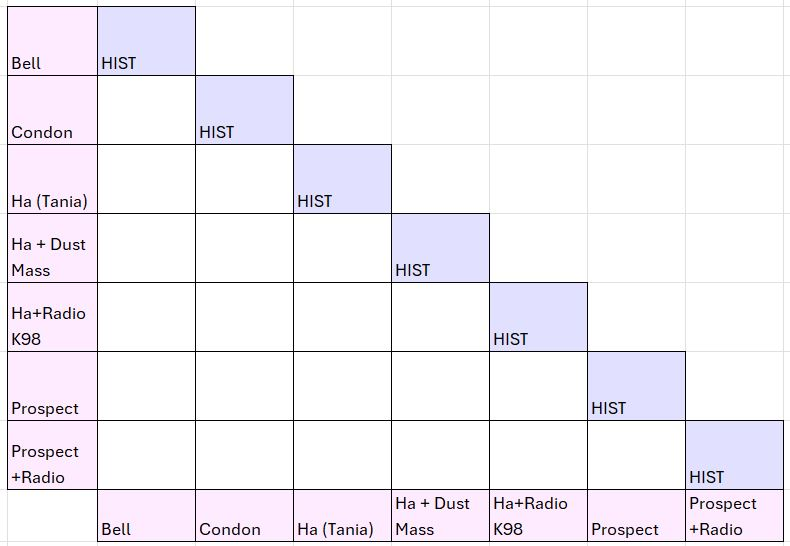

In [320]:
SFR_all= sample1[['Bell_SFR', 'Condon_SFR', 'Ha_SFR', 'K09_SFR', 'Ha_impr_SFR']].copy()

In [321]:
## ADD PROSPECT
SFR_all.insert(5, "Prospect_NoRadio_SFR", Prospect_NoRadio_SFR[:])
SFR_all.insert(6, "Prospect_Radio_SFR", Prospect_Radio_SFR[:])

In [322]:
SFR_all

,Bell_SFR,Condon_SFR,Ha_SFR,K09_SFR,Ha_impr_SFR,Prospect_NoRadio_SFR,Prospect_Radio_SFR
0,16.390270,35.317130,26.050823,3.002268,11.651385,6.483469,4.908914
2,30.198654,65.070910,34.471226,6.827026,16.642817,35.771830,38.464501
4,17.207058,37.077114,31.314770,1.792221,5.958650,4.299996,4.299996
10,3.463392,7.405838,16.299454,1.931737,2.994095,3.826066,3.443163
11,18.015107,38.818265,19.751650,2.541753,7.853745,5.935293,5.350184
...,...,...,...,...,...,...,...
5685,39.232040,84.535705,33.558102,4.711286,7.816354,4.209017,2.059620
5714,4.868773,10.491048,21.695238,2.127400,0.876827,14.327373,11.780931
5719,12.129569,26.136334,17.048174,2.648486,10.588110,18.985642,19.866253
5720,71.831150,154.779026,1.476702,0.583758,0.155855,1.440223,1.684221


In [323]:
#Raw Corner Plot
#sns_plot=sns.pairplot(np.log10(SFR_all), corner=True, height=2)
#sns_plot.set(xlim=(-2.2, 3.3), ylim=(-2.2,3.3))

#sns_plot.savefig('Corner.png')


In [324]:
#LOBF CORNER PLOT
#sns_plot=sns.pairplot(np.log10(SFR_all), corner=True, height=2)
#sns_plot.map_lower(sns.regplot, line_kws=dict(color="r"))
#sns_plot.add_legend()
#sns_plot.set(xlim=(-2.2, 3.3), ylim=(-2.2,3.3))

In [325]:
#Define a function for the 1-to-1 line
def plot_unity(xdata, ydata, **kwargs):
    mn = min(-2.2, -2.2)
    mx = max(3.3, 3.3)
    points = np.linspace(mn, mx, 100)
    plt.gca().plot(points, points, color='#272629', marker=None,
            linestyle='-', linewidth=2.0, alpha=0.4)


<Figure size 1800x1800 with 0 Axes>

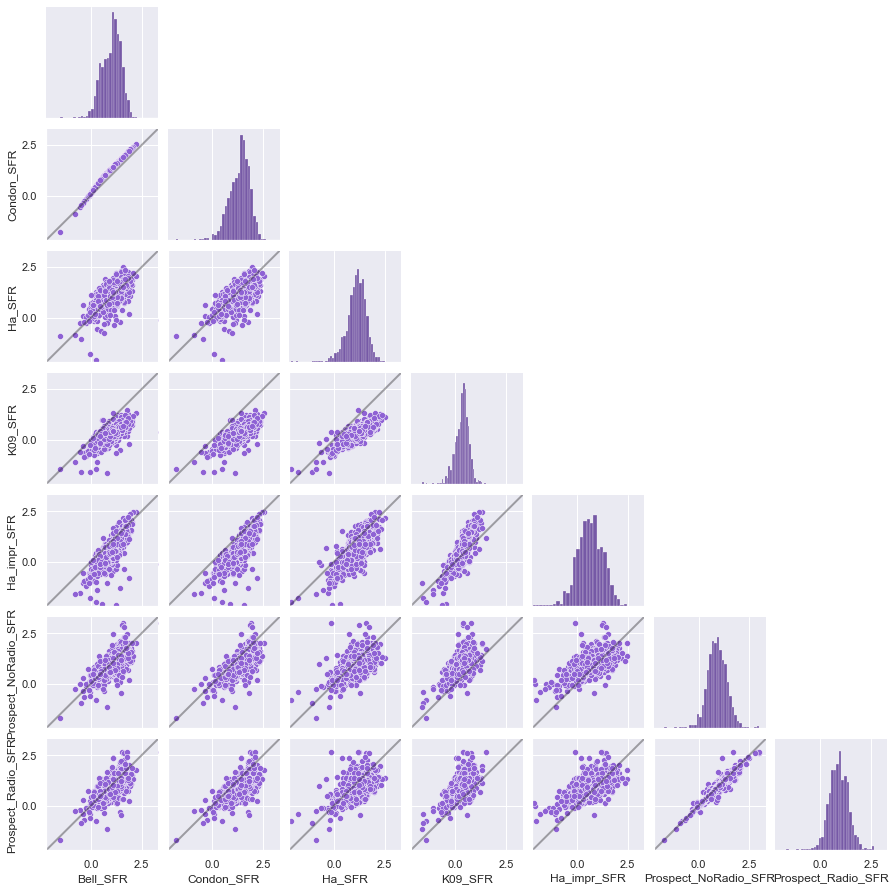

In [328]:
plt.figure(figsize=(25, 25))
sns_plot=sns.pairplot(np.log10(SFR_all), corner=True, height=1.8, plot_kws={'color':'#8e61d4'}, diag_kws= {'color': '#50288d'})

sns_plot.set(xlim=(-2.2, 3.3), ylim=(-2.2,3.3))
sns.set_theme(font_scale=1.45)
sns_plot.map_lower(plot_unity, color='#272629')
sns.set_style(rc = {'figure.facecolor': '#ffffff00'})
sns_plot.savefig('Corner.png', overwrite=True)
sns.set_theme(font_scale=10)

In [244]:
#sns_plot.savefig('Cornerlines.png')

## <span style='background :LightPink' > LOBF Gradient and Stats

In [179]:
#LOBF Function
def best_fit_slope_and_intercept(xs,ys):
    m = (((mean(xs)*mean(ys)) - mean(xs*ys)) /
         ((mean(xs)*mean(xs)) - mean(xs*xs)))
    
    b = mean(ys) - m*mean(xs)
    
    return m, b


In [329]:
mbs=[]
mbs.append(['BellvsCondon',best_fit_slope_and_intercept(SFR_all['Bell_SFR'],SFR_all['Condon_SFR'])])
mbs.append(['BellvsHa',best_fit_slope_and_intercept(SFR_all['Bell_SFR'],SFR_all['Ha_SFR'])])
mbs.append(['BellvsK09',best_fit_slope_and_intercept(SFR_all['Bell_SFR'],SFR_all['K09_SFR'])])
mbs.append(['BellvsDust',best_fit_slope_and_intercept(SFR_all['Bell_SFR'],SFR_all['Ha_impr_SFR'])])
mbs.append(['BellvsProspect_NoRadio',best_fit_slope_and_intercept(SFR_all['Bell_SFR'],SFR_all['Prospect_NoRadio_SFR'])])
mbs.append(['BellvsProspect_Radio',best_fit_slope_and_intercept(SFR_all['Bell_SFR'],SFR_all['Prospect_Radio_SFR'])])

mbs.append(['CondonvsHa',best_fit_slope_and_intercept(SFR_all['Condon_SFR'],SFR_all['Ha_SFR'])])
mbs.append(['CondonvsK09',best_fit_slope_and_intercept(SFR_all['Condon_SFR'],SFR_all['K09_SFR'])])
mbs.append(['CondonvsDust',best_fit_slope_and_intercept(SFR_all['Condon_SFR'],SFR_all['Ha_impr_SFR'])])
mbs.append(['CondonvsProspect_NoRadio',best_fit_slope_and_intercept(SFR_all['Condon_SFR'],SFR_all['Prospect_NoRadio_SFR'])])
mbs.append(['CondonvsProspect_Radio',best_fit_slope_and_intercept(SFR_all['Condon_SFR'],SFR_all['Prospect_Radio_SFR'])])


mbs.append(['HavsK09',best_fit_slope_and_intercept(SFR_all['Ha_SFR'],SFR_all['K09_SFR'])])
mbs.append(['HavsDust',best_fit_slope_and_intercept(SFR_all['Ha_SFR'],SFR_all['Ha_impr_SFR'])])
mbs.append(['HavsProspect_NoRadio',best_fit_slope_and_intercept(SFR_all['Ha_SFR'],SFR_all['Prospect_NoRadio_SFR'])])
mbs.append(['HavsProspect_Radio',best_fit_slope_and_intercept(SFR_all['Ha_SFR'],SFR_all['Prospect_Radio_SFR'])])

mbs.append(['K09vsDust',best_fit_slope_and_intercept(SFR_all['K09_SFR'],SFR_all['Ha_impr_SFR'])])
mbs.append(['K09vsProspect_NoRadio',best_fit_slope_and_intercept(SFR_all['K09_SFR'],SFR_all['Prospect_NoRadio_SFR'])])
mbs.append(['K09vsProspect_Radio',best_fit_slope_and_intercept(SFR_all['K09_SFR'],SFR_all['Prospect_Radio_SFR'])])

mbs.append(['DustvsProspect_NoRadio',best_fit_slope_and_intercept(SFR_all['Ha_impr_SFR'],SFR_all['Prospect_NoRadio_SFR'])])
mbs.append(['DustvsProspect_Radio',best_fit_slope_and_intercept(SFR_all['Ha_impr_SFR'],SFR_all['Prospect_Radio_SFR'])])

mbs.append(['Prospect_NoRadiovsProspect_Radio',best_fit_slope_and_intercept(SFR_all['Prospect_NoRadio_SFR'],SFR_all['Prospect_Radio_SFR'])])


## <span style='background :LightPink' > Scatter


In [330]:
#distance to the 1-to-1 line
def point_to_line_distance(x0, y0, slope, intercept):
    # Calculate the perpendicular distance
    distance = (slope * x0 - y0 + intercept) / np.sqrt(slope**2 + 1)
    return distance

In [184]:
# #distance to LOBF

dist_LOBF={'BellvsCondon': point_to_line_distance(SFR_all['Bell_SFR'],SFR_all['Condon_SFR'], mbs[0][1][0], mbs[0][1][1]),
        'BellvsHa': point_to_line_distance(SFR_all['Bell_SFR'],SFR_all['Ha_SFR'], mbs[1][1][0], mbs[1][1][1]),
        'BellvsK09': point_to_line_distance(SFR_all['Bell_SFR'],SFR_all['K09_SFR'], mbs[2][1][0], mbs[2][1][1]),
        'BellvsDust': point_to_line_distance(SFR_all['Bell_SFR'],SFR_all['Ha_impr_SFR'], mbs[3][1][0], mbs[3][1][1]),
        'BellvsProspect_NoRadio': point_to_line_distance(SFR_all['Bell_SFR'],SFR_all['Prospect_NoRadio_SFR'], mbs[4][1][0], mbs[4][1][1]),
        'BellvsProspect_Radio': point_to_line_distance(SFR_all['Bell_SFR'],SFR_all['Prospect_Radio_SFR'], mbs[5][1][0], mbs[5][1][1]),
      
        'CondonvsHa': point_to_line_distance(SFR_all['Condon_SFR'],SFR_all['Ha_SFR'], mbs[6][1][0], mbs[6][1][1]),
        'CondonvsK09': point_to_line_distance(SFR_all['Condon_SFR'],SFR_all['K09_SFR'], mbs[7][1][0], mbs[7][1][1]),
        'CondonvsDust': point_to_line_distance(SFR_all['Condon_SFR'],SFR_all['Ha_impr_SFR'], mbs[8][1][0], mbs[8][1][1]),
        'CondonvsProspect_NoRadio': point_to_line_distance(SFR_all['Condon_SFR'],SFR_all['Prospect_NoRadio_SFR'], mbs[9][1][0], mbs[9][1][1]),
        'CondonvsProspect_Radio': point_to_line_distance(SFR_all['Condon_SFR'],SFR_all['Prospect_Radio_SFR'], mbs[10][1][0], mbs[10][1][1]),
      
        'HavsK09':point_to_line_distance(SFR_all['Ha_SFR'],SFR_all['K09_SFR'], mbs[11][1][0], mbs[11][1][1]),
        'HavsDust': point_to_line_distance(SFR_all['Ha_SFR'],SFR_all['Ha_impr_SFR'], mbs[12][1][0], mbs[12][1][1]),
        'HavsProspect_NoRadio': point_to_line_distance(SFR_all['Ha_SFR'],SFR_all['Prospect_NoRadio_SFR'], mbs[13][1][0], mbs[13][1][1]),
        'HavsProspect_Radio': point_to_line_distance(SFR_all['Ha_SFR'],SFR_all['Prospect_Radio_SFR'], mbs[14][1][0], mbs[14][1][1]),
      
        'K09vsDust': point_to_line_distance(SFR_all['K09_SFR'],SFR_all['Ha_impr_SFR'], mbs[15][1][0], mbs[15][1][1]),
        'K09vsProspect_NoRadio': point_to_line_distance(SFR_all['K09_SFR'],SFR_all['Prospect_NoRadio_SFR'], mbs[16][1][0], mbs[16][1][1]),
        'K09vsProspect_Radio': point_to_line_distance(SFR_all['K09_SFR'],SFR_all['Prospect_Radio_SFR'], mbs[17][1][0], mbs[17][1][1]),
      
        'DustvsProspect_NoRadio': point_to_line_distance(SFR_all['Ha_impr_SFR'],SFR_all['Prospect_NoRadio_SFR'], mbs[18][1][0], mbs[18][1][1]),
        'DustvsProspect_Radio': point_to_line_distance(SFR_all['Ha_impr_SFR'],SFR_all['Prospect_Radio_SFR'], mbs[19][1][0], mbs[19][1][1]),
           
        'Prospect_NoRadiovsProspect_Radio': point_to_line_distance(SFR_all['Prospect_NoRadio_SFR'],SFR_all['Prospect_Radio_SFR'], mbs[20][1][0], mbs[20][1][1])
     
     }




dist_LOBF_df=pd.DataFrame(dist_LOBF)
#dist_LOBF_df

In [185]:
#Distance to the 1to1 line
dist={'BellvsCondon': point_to_line_distance(SFR_all['Bell_SFR'],SFR_all['Condon_SFR'], 1, 0),
        'BellvsHa': point_to_line_distance(SFR_all['Bell_SFR'],SFR_all['Ha_SFR'], 1, 0),
        'BellvsK09': point_to_line_distance(SFR_all['Bell_SFR'],SFR_all['K09_SFR'], 1, 0),
        'BellvsDust': point_to_line_distance(SFR_all['Bell_SFR'],SFR_all['Ha_impr_SFR'], 1, 0),
        'BellvsProspect_NoRadio': point_to_line_distance(SFR_all['Bell_SFR'],SFR_all['Prospect_NoRadio_SFR'], 1, 0),
        'BellvsProspect_Radio': point_to_line_distance(SFR_all['Bell_SFR'],SFR_all['Prospect_Radio_SFR'], 1, 0),
      
        'CondonvsHa': point_to_line_distance(SFR_all['Condon_SFR'],SFR_all['Ha_SFR'], 1, 0),
        'CondonvsK09': point_to_line_distance(SFR_all['Condon_SFR'],SFR_all['K09_SFR'], 1, 0),
        'CondonvsDust': point_to_line_distance(SFR_all['Condon_SFR'],SFR_all['Ha_impr_SFR'], 1, 0),
        'CondonvsProspect_NoRadio': point_to_line_distance(SFR_all['Condon_SFR'],SFR_all['Prospect_NoRadio_SFR'], 1, 0),
        'CondonvsProspect_Radio': point_to_line_distance(SFR_all['Condon_SFR'],SFR_all['Prospect_Radio_SFR'], 1, 0),
      
        'HavsK09':point_to_line_distance(SFR_all['Ha_SFR'],SFR_all['K09_SFR'], 1, 0),
        'HavsDust': point_to_line_distance(SFR_all['Ha_SFR'],SFR_all['Ha_impr_SFR'], 1, 0),
        'HavsProspect_NoRadio': point_to_line_distance(SFR_all['Ha_SFR'],SFR_all['Prospect_NoRadio_SFR'], 1, 0),
        'HavsProspect_Radio': point_to_line_distance(SFR_all['Ha_SFR'],SFR_all['Prospect_Radio_SFR'], 1, 0),
      
        'K09vsDust': point_to_line_distance(SFR_all['K09_SFR'],SFR_all['Ha_impr_SFR'], 1, 0),
        'K09vsProspect_NoRadio': point_to_line_distance(SFR_all['K09_SFR'],SFR_all['Prospect_NoRadio_SFR'], 1, 0),
        'K09vsProspect_Radio': point_to_line_distance(SFR_all['K09_SFR'],SFR_all['Prospect_Radio_SFR'], 1, 0),
      
        'DustvsProspect_NoRadio': point_to_line_distance(SFR_all['Ha_impr_SFR'],SFR_all['Prospect_NoRadio_SFR'], 1,0),
        'DustvsProspect_Radio': point_to_line_distance(SFR_all['Ha_impr_SFR'],SFR_all['Prospect_Radio_SFR'], 1,0),
      
        'Prospect_NoRadiovsProspect_Radio': point_to_line_distance(SFR_all['Prospect_NoRadio_SFR'],SFR_all['Prospect_Radio_SFR'], 1, 0)
     
     }
dist_df=pd.DataFrame(dist)
#dist_df

### <span style='background :LightPink' > Plots!


D:\anaconda\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
D:\anaconda\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
D:\anaconda\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings

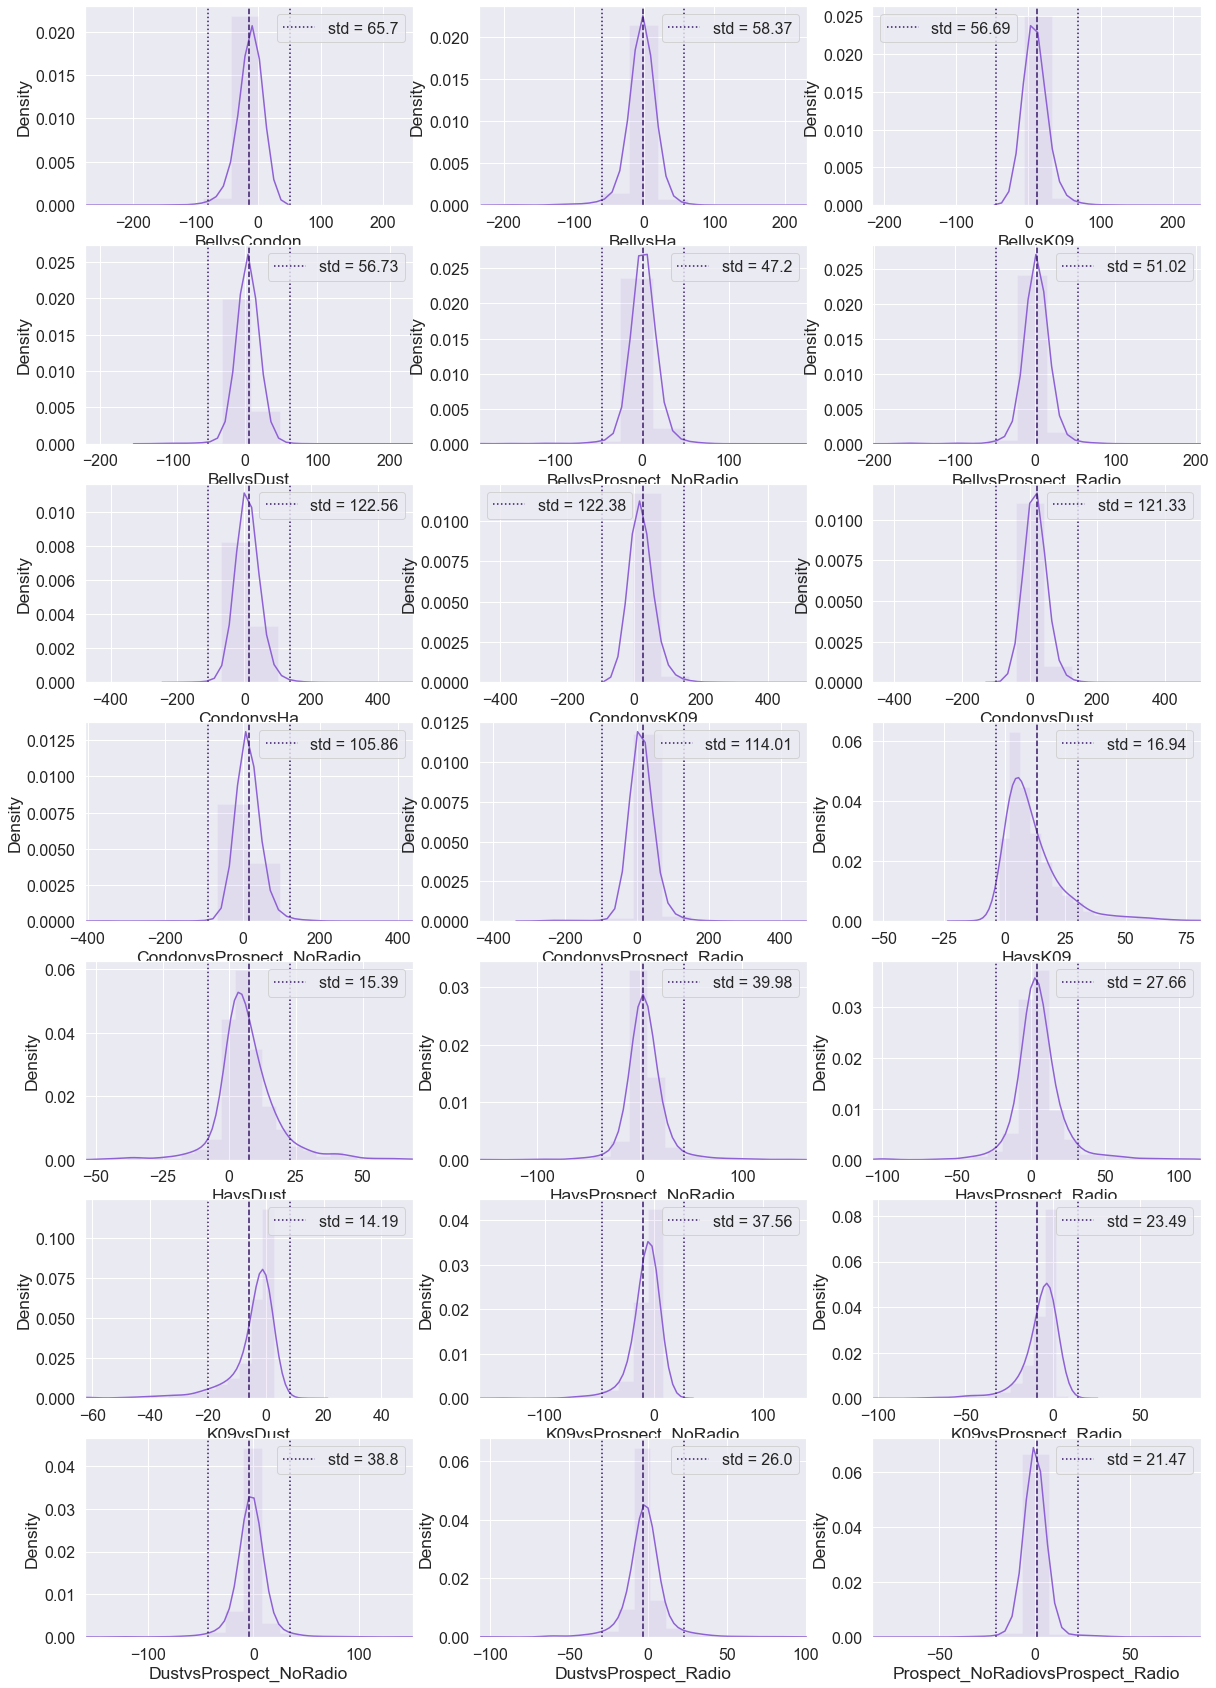

In [186]:

fig, axes = plt.subplots(7,3, figsize=(20, 30))
for name, ax in zip(dist_df.columns.values, axes.flatten()):
    sns.distplot(dist_df[name],
                 kde_kws={"color": "#8e61d4", "lw": 1.5},
                 hist_kws={"histtype": "stepfilled", "linewidth": 1, "alpha": 0.1, "color": "#8e61d4"},
                 norm_hist=True,  
                 ax=ax)
    #print(ax)
    ax.axvline(dist_df[name].mean()-dist_df[name].std(), linestyle=':', color='#361666', label=("std = {}".format(round(dist_df[name].std(),2))))
    ax.axvline(dist_df[name].mean()+dist_df[name].std(), linestyle=':', color='#361666')
    ax.axvline(dist_df[name].mean(), linestyle='--', color='#361666')
    ax.set_xlim(dist_df[name].mean()-4*dist_df[name].std(), dist_df[name].mean()+4*dist_df[name].std() )
    ax.legend()
    
#fig.delaxes(axes[-1, -1])
#fig.delaxes(axes[-1, -2])



In [188]:
#find the standard deviation
std=[]
for name in dist_df.columns.values:
     std.append(["{}".format(name), round(dist_df[name].std(),2)])
     #print(name)
    
#std

### <span style='background :LightPink' > Fit Gaussians for sd!


In [189]:
#gaussian fit function
def gaussian(x, a, mu, sigma):
        return a*np.exp(-(x-mu)**2/(2*sigma**2))

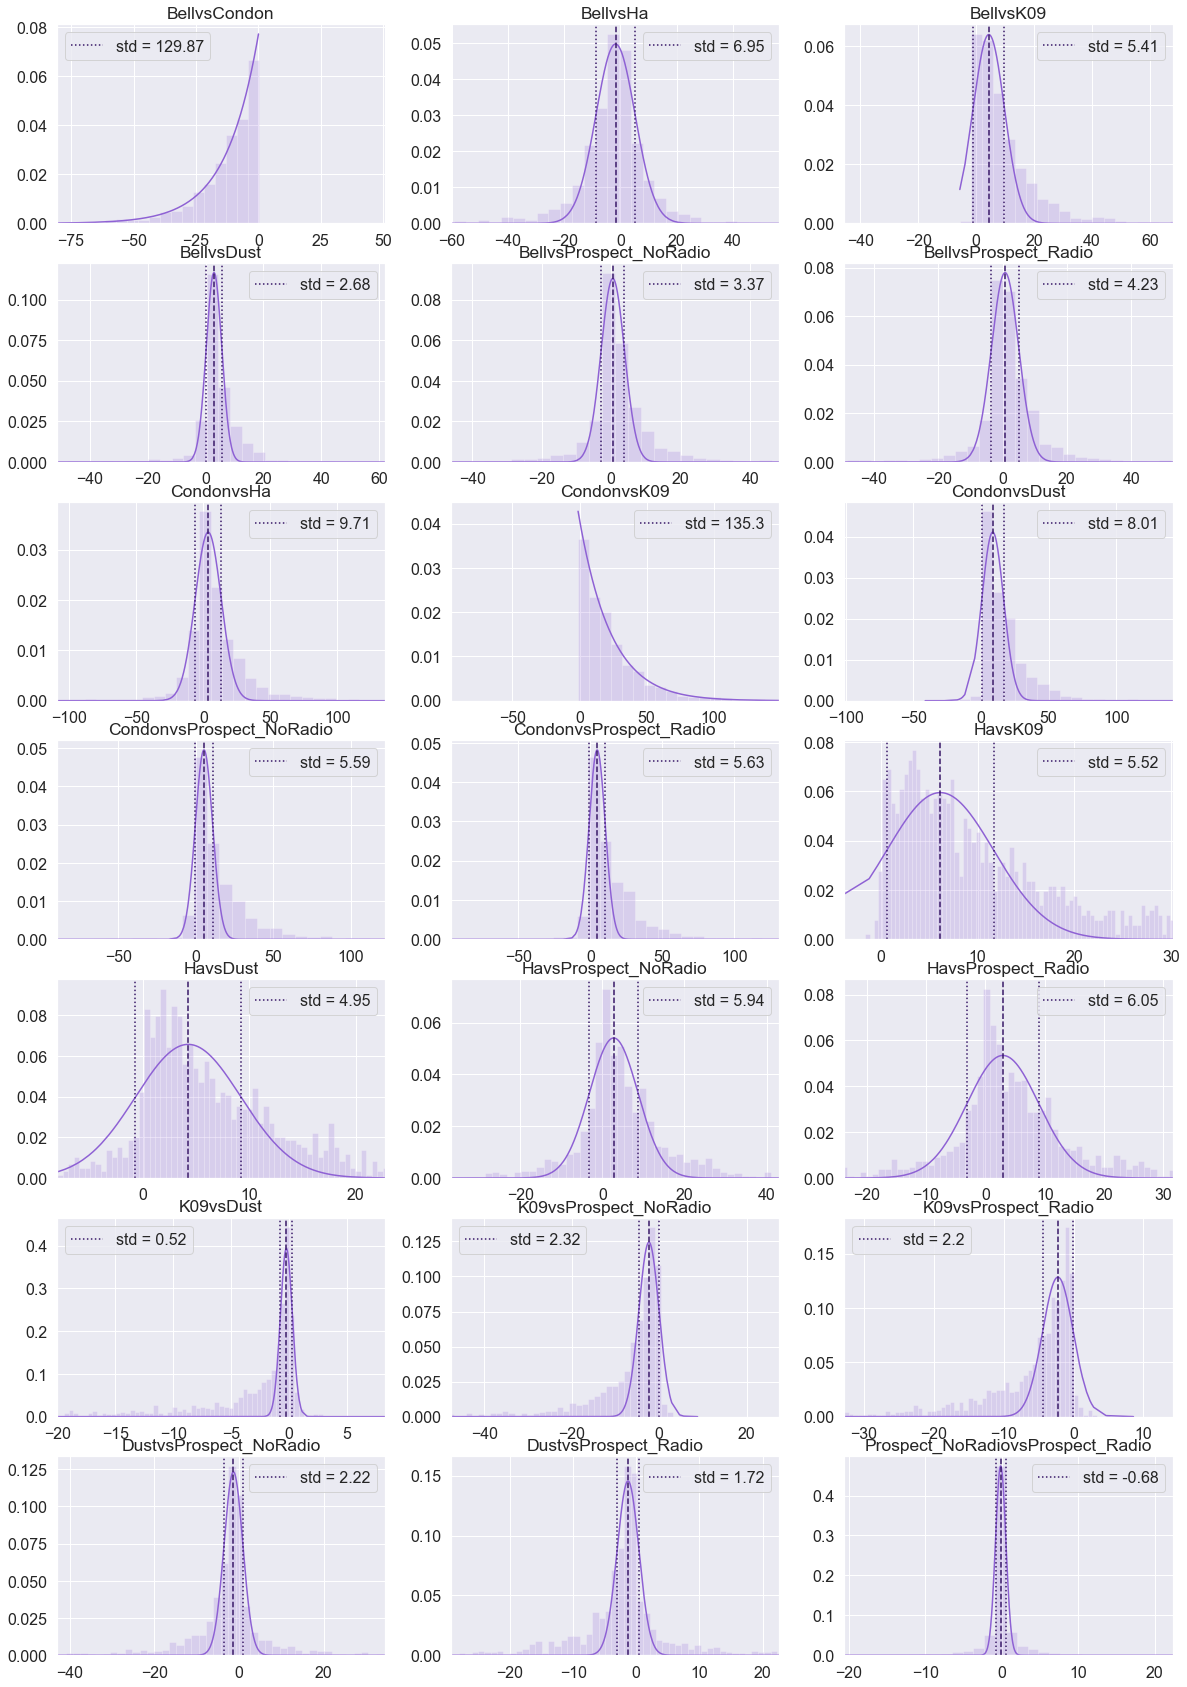

In [191]:
fig, axes = plt.subplots(7,3, figsize=(20, 30))
counts=[]
i=0
for name, ax in zip(dist_df.columns.values, axes.flatten()):
    
    bins=500
    
    try: 
        counts, bins, patches = ax.hist(dist_df[name].sort_values(), bins = bins, color = '#8e61d4', density = True, alpha=0.2)
    finally:
        
    
        bins= (bins[:-1] + np.diff(bins) / 2)

        #ax.axvline(dist_df[name].mean()-dist_df[name].std(), linestyle=':', color='#361666', label=("std = {}".format(round(dist_df[name].std(),2))))
        #ax.axvline(dist_df[name].mean()+dist_df[name].std(), linestyle=':', color='#361666')
        #ax.axvline(dist_df[name].mean(), linestyle='--', color='#361666')

        param, cov = curve_fit(gaussian, bins, counts, p0=(0,1,10), maxfev=100000)

        ax.plot(dist_df[name].sort_values(), gaussian(dist_df[name].sort_values(), *param), '-', color = '#8e61d4', lw=1.5)

        amp_gaus  = param[0] #amplitude 
        mean_gaus = param[1] #mean of gaussian dist
        std_gau   = param[2] #stdev of the dist

        #plt.legend(loc = 0, fontsize = 8)

        ax.set_xlim(dist_df[name].mean()-dist_df[name].std(), dist_df[name].mean()+dist_df[name].std() )
        
        ax.title.set_text(name)
        
        ax.axvline(mean_gaus-std_gau, linestyle=':', color='#361666', label=("std = {}".format(round(std_gau,2))))
        ax.axvline(mean_gaus+std_gau, linestyle=':', color='#361666')
        ax.axvline(mean_gaus, linestyle='--', color='#361666')
        
        
        ax.legend()
    
#fig.delaxes(axes[-1, -1])
#fig.delaxes(axes[-1, -2])

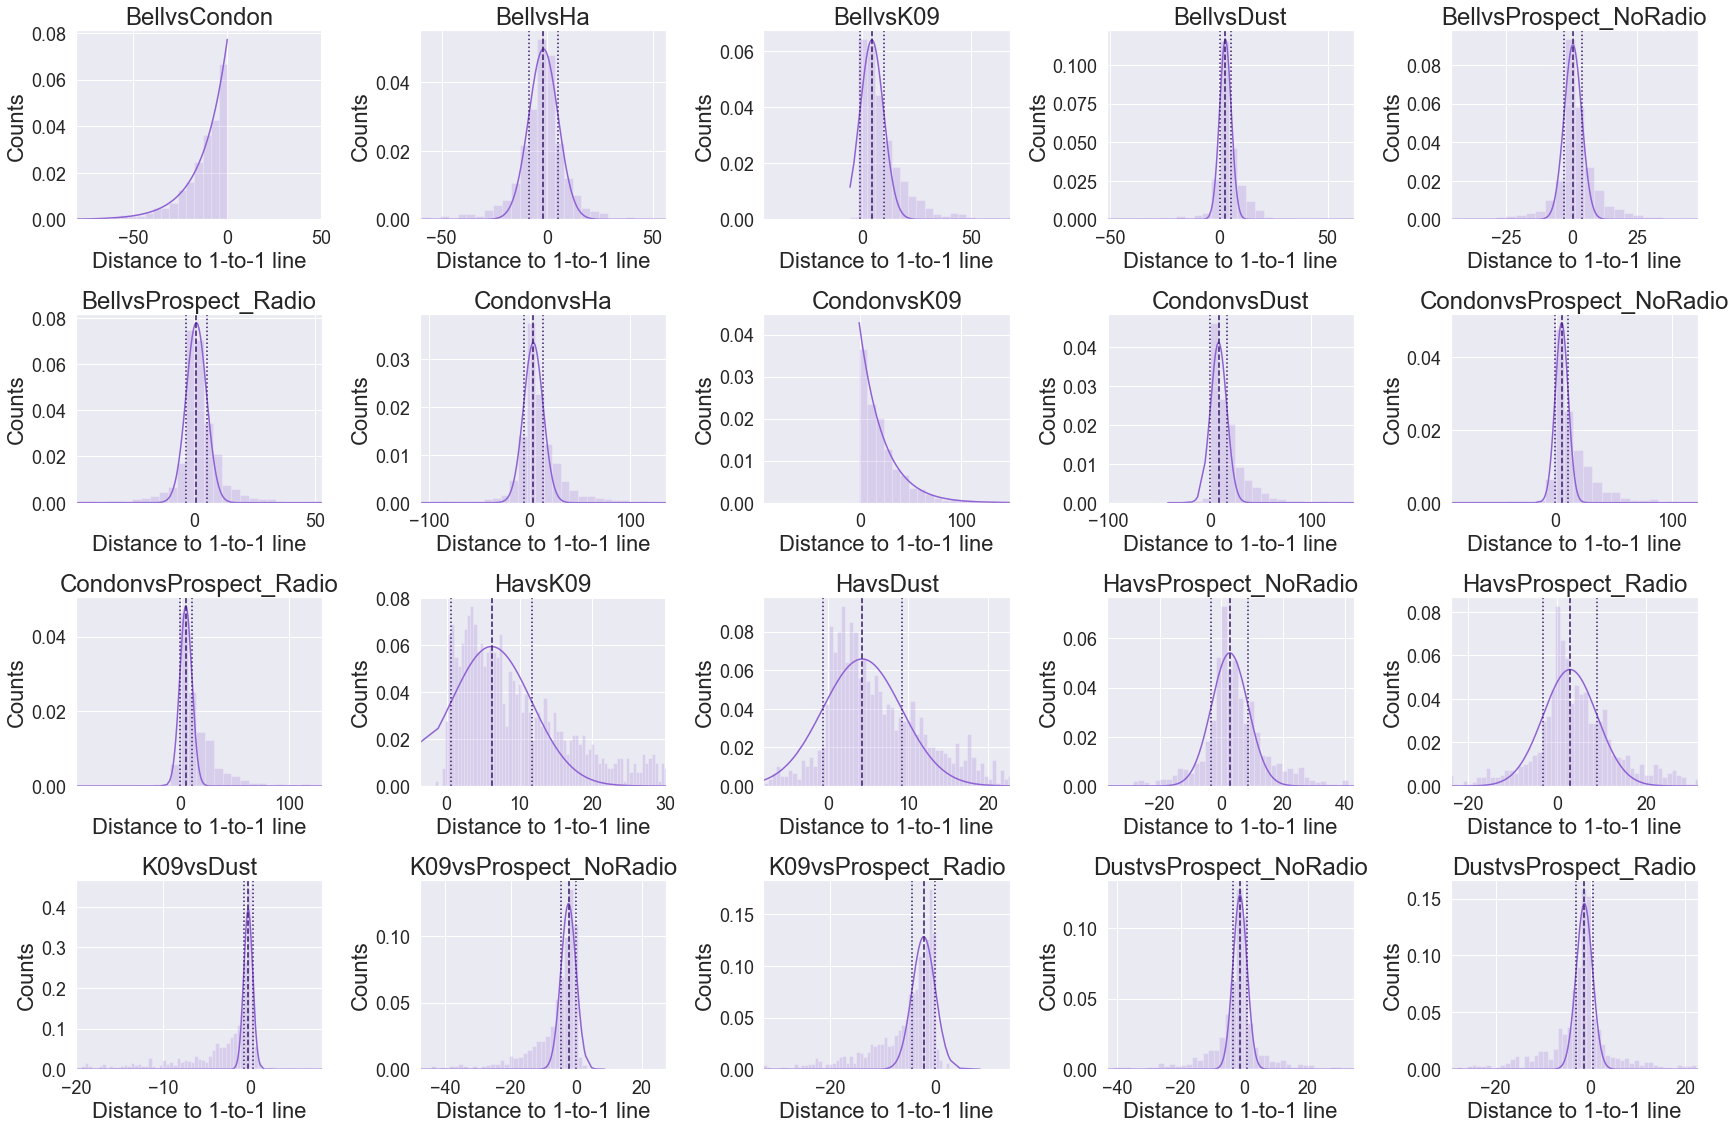

In [192]:
fig, axes = plt.subplots(4,5, figsize=(24, 16))
counts=[]
i=0
for name, ax in zip(dist_df.columns.values, axes.flatten()):
    
    bins=500
    
    try: 
        counts, bins, patches = ax.hist(dist_df[name].sort_values(), bins = bins, color = '#8e61d4', density = True, alpha=0.2)
    finally:
        
    
        bins= (bins[:-1] + np.diff(bins) / 2)

        #ax.axvline(dist_df[name].mean()-dist_df[name].std(), linestyle=':', color='#361666', label=("std = {}".format(round(dist_df[name].std(),2))))
        #ax.axvline(dist_df[name].mean()+dist_df[name].std(), linestyle=':', color='#361666')
        #ax.axvline(dist_df[name].mean(), linestyle='--', color='#361666')

        param, cov = curve_fit(gaussian, bins, counts, p0=(0,1,10), maxfev=100000)

        ax.plot(dist_df[name].sort_values(), gaussian(dist_df[name].sort_values(), *param), '-', color = '#8e61d4', lw=1.5)

        amp_gaus  = param[0] #amplitude 
        mean_gaus = param[1] #mean of gaussian dist
        std_gau   = param[2] #stdev of the dist

        #plt.legend(loc = 0, fontsize = 8)

        ax.set_xlim(dist_df[name].mean()-dist_df[name].std(), dist_df[name].mean()+dist_df[name].std() )
        
        #ax.title.set_text(name)
        ax.set_title(name, fontsize=24)
        
        ax.axvline(mean_gaus-std_gau, linestyle=':', color='#361666', label=("std = {}".format(round(std_gau,2))))
        ax.axvline(mean_gaus+std_gau, linestyle=':', color='#361666')
        ax.axvline(mean_gaus, linestyle='--', color='#361666')
        
        ax.set_xlabel('Distance to 1-to-1 line', fontsize=22)
        ax.set_ylabel('Counts', fontsize=22)
        
        ax.tick_params(axis='both', which='major', labelsize=18)
        
        fig.tight_layout()
        #ax.legend(fontsize=16)
    
#fig.delaxes(axes[-1, -1])
#fig.delaxes(axes[-1, -2])

### <span style='background :LightPink' > Mean distances to 1to1
   


In [205]:
mean_dists=(['BellvsCondon',np.mean(dist_df['BellvsCondon'])],
        ['BellvsHa', np.mean(dist_df['BellvsHa'])],
        ['BellvsK09', np.mean(dist_df['BellvsK09'])],
        ['BellvsDust', np.mean(dist_df['BellvsDust'])],
        ['BellvsProspect_NoRadio', np.mean(dist_df['BellvsProspect_NoRadio'])],
        ['BellvsProspect_Radio', np.mean(dist_df['BellvsProspect_Radio'])],
            
        ['CondonvsHa', np.mean(dist_df['CondonvsHa'])],
        ['CondonvsK09',np.mean(dist_df['CondonvsK09'])],
        ['CondonvsDust', np.mean(dist_df['CondonvsDust'])],
        ['CondonvsProspect_NoRadio', np.mean(dist_df['CondonvsProspect_NoRadio'])],
        ['CondonvsProspect_Radio', np.mean(dist_df['CondonvsProspect_Radio'])],
            
        ['HavsK09', np.mean(dist_df['HavsK09'])],
        ['HavsDust', np.mean(dist_df['HavsDust'])],
        ['HavsProspect_NoRadio', np.mean(dist_df['HavsProspect_NoRadio'])],
        ['HavsProspect_Radio', np.mean(dist_df['HavsProspect_Radio'])],
            
        ['K09vsDust', np.mean(dist_df['K09vsDust'])],
        ['K09vsProspect_NoRadio', np.mean(dist_df['K09vsProspect_NoRadio'])],
        ['K09vsProspect_Radio', np.mean(dist_df['K09vsProspect_Radio'])],
            
        ['Prospect_NoRadiovsProspect_Radio', np.mean(dist_df['Prospect_NoRadiovsProspect_Radio'])]
           
           )

In [206]:
#mean_dists

### <span style='background :LightPink' > Correlation Coefficient

In [207]:
corrcoef=[]

corrcoef.append(['BellvsCondon',np.corrcoef(SFR_all['Bell_SFR'],SFR_all['Condon_SFR'])[0,1]])
corrcoef.append(['BellvsHa',np.corrcoef(SFR_all['Bell_SFR'],SFR_all['Ha_SFR'])[0,1]])
corrcoef.append(['BellvsK09',np.corrcoef(SFR_all['Bell_SFR'],SFR_all['K09_SFR'])[0,1]])
corrcoef.append(['BellvsDust',np.corrcoef(SFR_all['Bell_SFR'],SFR_all['Ha_impr_SFR'])[0,1]])
corrcoef.append(['BellvsProspect_NoRadio',np.corrcoef(SFR_all['Bell_SFR'],SFR_all['Prospect_NoRadio_SFR'])[0,1]])
corrcoef.append(['BellvsProspect_Radio',np.corrcoef(SFR_all['Bell_SFR'],SFR_all['Prospect_Radio_SFR'])[0,1]])

corrcoef.append(['CondonvsHa',np.corrcoef(SFR_all['Condon_SFR'],SFR_all['Ha_SFR'])[0,1]])
corrcoef.append(['CondonvsK09',np.corrcoef(SFR_all['Condon_SFR'],SFR_all['K09_SFR'])[0,1]])
corrcoef.append(['CondonvsDust',np.corrcoef(SFR_all['Condon_SFR'],SFR_all['Ha_impr_SFR'])[0,1]])
corrcoef.append(['CondonvsProspect_NoRadio',np.corrcoef(SFR_all['Condon_SFR'],SFR_all['Prospect_NoRadio_SFR'])[0,1]])
corrcoef.append(['CondonvsProspect_Radio',np.corrcoef(SFR_all['Condon_SFR'],SFR_all['Prospect_Radio_SFR'])[0,1]])

corrcoef.append(['HavsK09',np.corrcoef(SFR_all['Ha_SFR'],SFR_all['K09_SFR'])[0,1]])
corrcoef.append(['HavsDust',np.corrcoef(SFR_all['Ha_SFR'],SFR_all['Ha_impr_SFR'])[0,1]])
corrcoef.append(['HavsProspect_NoRadio',np.corrcoef(SFR_all['Ha_SFR'],SFR_all['Prospect_NoRadio_SFR'])[0,1]])
corrcoef.append(['HavsProspect_Radio',np.corrcoef(SFR_all['Ha_SFR'],SFR_all['Prospect_Radio_SFR'])[0,1]])

corrcoef.append(['K09vsDust',np.corrcoef(SFR_all['K09_SFR'],SFR_all['Ha_impr_SFR'])[0,1]])
corrcoef.append(['K09vsProspect_NoRadio',np.corrcoef(SFR_all['K09_SFR'],SFR_all['Prospect_NoRadio_SFR'])[0,1]])
corrcoef.append(['K09vsProspect_Radio',np.corrcoef(SFR_all['K09_SFR'],SFR_all['Prospect_Radio_SFR'])[0,1]])

corrcoef.append(['Prospect_NoRadiovsProspect_Radio',np.corrcoef(SFR_all['Prospect_NoRadio_SFR'],SFR_all['Prospect_Radio_SFR'])[0,1]])


In [208]:
#corrcoef

## <span style='background :LightPink' > SUMMARY STATS FOR CORNER PLOT

In [209]:
print("\033[1mBellvsCondon Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['BellvsCondon'] , "\n\n Distance to the 1-to-1 line", dist_df['BellvsCondon'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['BellvsCondon'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['BellvsCondon'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

BellvsCondon Values

 Distance to line of best fit:
 0      -0.049427
2      -0.047692
3      -0.047467
4      -0.049324
10     -0.027082
          ...   
5714   -0.050875
5719   -0.049963
5720   -0.042459
5722   -0.049972
5723    0.308667
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0      -13.383311
2      -24.658408
3      -26.117954
4      -14.050251
10      -2.787730
          ...    
5714    -3.975548
5719    -9.904278
5720   -58.653006
5722    -9.840588
5723    -0.549457
Name: BellvsCondon, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: -15.061189878749664 

 The standard deviation of the distances to the 1-to-1 line is:  65.70262712998867 

 The correlation coefficient between them is: 0.07440378332932153


In [210]:
print("\033[1mBellvsHa Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['BellvsHa'] , "\n\n Distance to the 1-to-1 line", dist_df['BellvsHa'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['BellvsHa'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['BellvsHa'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

BellvsHa Values

 Distance to line of best fit:
 0       -4.677122
2      -12.770156
3      -21.673871
4       -9.920384
10       4.767260
          ...    
5714    -0.593948
5719     4.222740
5720    21.195211
5722     3.555672
5723    19.549354
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0       -6.831042
2       -3.021164
3       -8.084609
4       -9.975658
10      -9.076466
          ...    
5714   -11.898107
5719    -3.477979
5720    49.748108
5722    -4.003654
5723    -0.036405
Name: BellvsHa, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: -2.0342767787417504 

 The standard deviation of the distances to the 1-to-1 line is:  58.371580746087616 

 The correlation coefficient between them is: 0.07440378332932153


In [211]:
print("\033[1mBellvsK09 Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['BellvsK09'] , "\n\n Distance to the 1-to-1 line", dist_df['BellvsK09'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['BellvsK09'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['BellvsK09'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

BellvsK09 Values

 Distance to line of best fit:
 0      -0.261578
2      -4.033602
3      -0.897465
4       0.951577
10      0.759603
          ...   
5714    0.569306
5719    0.075938
5720    2.368531
5722    0.029710
5723    2.235677
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0        9.466747
2       16.526237
3       20.002949
4       10.899936
10       1.083044
          ...    
5714     1.938444
5719     6.704138
5720    50.379514
5722     6.616506
5723     0.682843
Name: BellvsK09, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 11.170413112567632 

 The standard deviation of the distances to the 1-to-1 line is:  56.69008935408922 

 The correlation coefficient between them is: 0.07440378332932153


In [212]:
print("\033[1mBellvsDust Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['BellvsDust'] , "\n\n Distance to the 1-to-1 line", dist_df['BellvsDust'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['BellvsDust'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['BellvsDust'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

BellvsDust Values

 Distance to line of best fit:
 0       -0.671460
2       -5.125723
3       10.302325
4        5.048579
10       7.479978
          ...    
5714     9.649958
5719     0.226423
5720    12.957271
5722     2.911615
5723     9.888258
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0        3.350898
2        9.585425
3       21.717923
4        7.953826
10       0.331843
          ...    
5714     2.822732
5719     1.089976
5720    50.682087
5722     2.937090
5723     0.642581
Name: BellvsDust, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 5.291627668240269 

 The standard deviation of the distances to the 1-to-1 line is:  56.73265766678526 

 The correlation coefficient between them is: 0.07440378332932153


In [213]:
print("\033[1mBellvsProspect_NoRadio Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['BellvsProspect_NoRadio'] , "\n\n Distance to the 1-to-1 line", dist_df['BellvsProspect_NoRadio'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['BellvsProspect_NoRadio'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['BellvsProspect_NoRadio'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

BellvsProspect_NoRadio Values

 Distance to line of best fit:
 0        9.234762
2      -13.315032
3       14.872316
4       11.566001
10       7.169832
          ...    
5714    -2.163929
5719    -3.966976
5720    33.478112
5722     3.949546
5723     8.480734
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0        7.005166
2       -3.940831
3       18.143086
4        9.126671
10      -0.256449
          ...    
5714    -6.688240
5719    -4.847976
5720    49.773902
5722     1.098550
5723    -0.170188
Name: BellvsProspect_NoRadio, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 0.9792377667221346 

 The standard deviation of the distances to the 1-to-1 line is:  47.204041762341284 

 The correlation coefficient between them is: 0.07440378332932153


In [214]:
print("\033[1mBellvsProspect_Radio Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['BellvsProspect_Radio'] , "\n\n Distance to the 1-to-1 line", dist_df['BellvsProspect_Radio'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['BellvsProspect_Radio'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['BellvsProspect_Radio'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

BellvsProspect_Radio Values

 Distance to line of best fit:
 0       10.403708
2      -20.047435
3       11.834865
4       11.152196
10       9.471948
          ...    
5714     1.533766
5719    -5.081549
5720    23.749292
5722     4.248289
5723    10.858657
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0        8.118545
2       -5.844837
3       18.116895
4        9.126671
10       0.014304
          ...    
5714    -4.887634
5719    -5.470661
5720    49.601369
5722     1.195683
5723    -0.167045
Name: BellvsProspect_Radio, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 1.874752811165785 

 The standard deviation of the distances to the 1-to-1 line is:  51.01852135662527 

 The correlation coefficient between them is: 0.07440378332932153


In [215]:
print("\033[1mCondonvsHa Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['CondonvsHa'] , "\n\n Distance to the 1-to-1 line", dist_df['CondonvsHa'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['CondonvsHa'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['CondonvsHa'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

CondonvsHa Values

 Distance to line of best fit:
 0       -4.677107
2      -12.770275
3      -21.675710
4       -9.921410
10       4.767180
          ...    
5714    -0.594400
5719     4.224185
5720    21.207347
5722     3.556963
5723    19.543473
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0         6.552269
2        21.637244
3        18.033344
4         4.074593
10       -6.288736
           ...    
5714     -7.922559
5719      6.426299
5720    108.401113
5722      5.836934
5723      0.513052
Name: CondonvsHa, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 13.026913100007931 

 The standard deviation of the distances to the 1-to-1 line is:  122.56014701455028 

 The correlation coefficient between them is: 0.07440378332932153


In [216]:
print("\033[1mCondonvsK09 Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['CondonvsK09'] , "\n\n Distance to the 1-to-1 line", dist_df['CondonvsK09'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['CondonvsK09'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['CondonvsK09'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

CondonvsK09 Values

 Distance to line of best fit:
 0      -0.261403
2      -4.033250
3      -0.897069
4       0.951771
10      0.759498
          ...   
5714    0.569320
5719    0.076054
5720    2.369517
5722    0.029825
5723    2.234131
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0        22.850058
2        41.184645
3        46.120903
4        24.950187
10        3.870774
           ...    
5714      5.913992
5719     16.608416
5720    109.032520
5722     16.457093
5723      1.232300
Name: CondonvsK09, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 26.231602991317345 

 The standard deviation of the distances to the 1-to-1 line is:  122.3783190459184 

 The correlation coefficient between them is: 0.07440378332932153


In [217]:
print("\033[1mCondonvsDust Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['CondonvsDust'] , "\n\n Distance to the 1-to-1 line", dist_df['CondonvsDust'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['CondonvsDust'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['CondonvsDust'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

CondonvsDust Values

 Distance to line of best fit:
 0       -0.669914
2       -5.125763
3       10.311449
4        5.053535
10       7.484317
          ...    
5714     9.656694
5719     0.228180
5720    12.970896
5722     2.914938
5723     9.879507
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0        16.734209
2        34.243833
3        47.835877
4        22.004077
10        3.119574
           ...    
5714      6.798280
5719     10.994255
5720    109.335093
5722     12.777678
5723      1.192038
Name: CondonvsDust, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 20.35281754698997 

 The standard deviation of the distances to the 1-to-1 line is:  121.32575631387073 

 The correlation coefficient between them is: 0.07440378332932153


In [218]:
print("\033[1mCondonvsProspect_NoRadio Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['CondonvsProspect_NoRadio'] , "\n\n Distance to the 1-to-1 line", dist_df['CondonvsProspect_NoRadio'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['CondonvsProspect_NoRadio'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['CondonvsProspect_NoRadio'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

CondonvsProspect_NoRadio Values

 Distance to line of best fit:
 0        9.739762
2      -13.994004
3       15.673546
4       12.193430
10       7.556446
          ...    
5714    -2.257640
5719    -4.155280
5720    35.256857
5722     4.176955
5723     8.798848
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0        20.388477
2        20.717578
3        44.261040
4        23.176922
10        2.531282
           ...    
5714     -2.712692
5719      5.056302
5720    108.426908
5722     10.939137
5723      0.379270
Name: CondonvsProspect_NoRadio, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 16.04042764547179 

 The standard deviation of the distances to the 1-to-1 line is:  105.8606222067954 

 The correlation coefficient between them is: 0.07440378332932153


In [219]:
print("\033[1mCondonvsProspect_Radio Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['CondonvsProspect_Radio'] , "\n\n Distance to the 1-to-1 line", dist_df['CondonvsProspect_Radio'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['CondonvsProspect_Radio'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['CondonvsProspect_Radio'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

CondonvsProspect_Radio Values

 Distance to line of best fit:
 0       10.553934
2      -20.306989
3       12.005232
4       11.312557
10       9.603993
          ...    
5714     1.563786
5719    -5.140320
5720    24.082447
5722     4.315294
5723    10.940353
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0        21.501856
2        18.813572
3        44.234849
4        23.176922
10        2.802035
           ...    
5714     -0.912086
5719      4.433617
5720    108.254375
5722     11.036271
5723      0.382412
Name: CondonvsProspect_Radio, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 16.93594268991544 

 The standard deviation of the distances to the 1-to-1 line is:  114.00695754575084 

 The correlation coefficient between them is: 0.07440378332932153


In [220]:
print("\033[1mHavsK09 Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['HavsK09'] , "\n\n Distance to the 1-to-1 line", dist_df['HavsK09'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['HavsK09'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['HavsK09'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

HavsK09 Values

 Distance to line of best fit:
 0       0.030857
2      -3.270432
3       0.401656
4       1.561372
10      0.501497
          ...   
5714    0.637029
5719   -0.167998
5720    0.938125
5722   -0.173044
5723    1.073082
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0       16.297790
2       19.547401
3       28.087558
4       20.875594
10      10.159510
          ...    
5714    13.836551
5719    10.182117
5720     0.631406
5722    10.620160
5723     0.719248
Name: HavsK09, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 13.204689891309389 

 The standard deviation of the distances to the 1-to-1 line is:  16.94400800867977 

 The correlation coefficient between them is: 0.07440378332932153


In [221]:
print("\033[1mHavsDust Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['HavsDust'] , "\n\n Distance to the 1-to-1 line", dist_df['HavsDust'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['HavsDust'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['HavsDust'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

HavsDust Values

 Distance to line of best fit:
 0        1.522847
2        0.779260
3       18.523437
4        8.958683
10       4.963019
          ...    
5714     9.251968
5719    -1.513040
5720     0.939444
5722     1.193507
5723     0.621468
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0       10.181940
2       12.606589
3       29.802533
4       17.929484
10       9.408310
          ...    
5714    14.720839
5719     4.567955
5720     0.933980
5722     6.940744
5723     0.678986
Name: HavsDust, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 7.325904446982032 

 The standard deviation of the distances to the 1-to-1 line is:  15.391632868345177 

 The correlation coefficient between them is: 0.07440378332932153


In [222]:
print("\033[1mHavsProspect_NoRadio Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['HavsProspect_NoRadio'] , "\n\n Distance to the 1-to-1 line", dist_df['HavsProspect_NoRadio'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['HavsProspect_NoRadio'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['HavsProspect_NoRadio'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

HavsProspect_NoRadio Values

 Distance to line of best fit:
 0       11.454475
2      -15.123353
3       15.587791
4       14.786599
10      11.805512
          ...    
5714     2.820933
5719    -2.778646
5720    10.729562
5722     5.635500
5723    10.518606
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0       13.836209
2       -0.919666
3       26.227695
4       19.102330
10       8.820017
          ...    
5714     5.209867
5719    -1.369997
5720     0.025794
5722     5.102204
5723    -0.133783
Name: HavsProspect_NoRadio, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 3.013514545463882 

 The standard deviation of the distances to the 1-to-1 line is:  39.98449364892712 

 The correlation coefficient between them is: 0.07440378332932153


In [223]:
print("\033[1mHavsProspect_Radio Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['HavsProspect_Radio'] , "\n\n Distance to the 1-to-1 line", dist_df['HavsProspect_Radio'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['HavsProspect_Radio'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['HavsProspect_Radio'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

HavsProspect_Radio Values

 Distance to line of best fit:
 0       11.696895
2      -19.449552
3       13.798293
4       13.362093
10      11.151861
          ...    
5714     4.083563
5719    -4.776984
5720     9.864046
5722     4.665716
5723     9.895422
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0       14.949587
2       -2.823672
3       26.201505
4       19.102329
10       9.090770
          ...    
5714     7.010474
5719    -1.992683
5720    -0.146739
5722     5.199337
5723    -0.130640
Name: HavsProspect_Radio, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 3.909029589907539 

 The standard deviation of the distances to the 1-to-1 line is:  27.661854832009016 

 The correlation coefficient between them is: 0.07440378332932153


In [224]:
print("\033[1mK09vsDust Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['K09vsDust'] , "\n\n Distance to the 1-to-1 line", dist_df['K09vsDust'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['K09vsDust'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['K09vsDust'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

K09vsDust Values

 Distance to line of best fit:
 0       0.153520
2       3.109066
3       2.539553
4      -0.107760
10      0.515442
          ...   
5714    1.055255
5719   -0.021328
5720   -0.349450
5722    0.464618
5723   -0.540694
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0      -6.115849
2      -6.940812
3       1.714974
4      -2.946110
10     -0.751200
          ...   
5714    0.884289
5719   -5.614162
5720    0.302573
5722   -3.679415
5723   -0.040262
Name: K09vsDust, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: -5.878785444327374 

 The standard deviation of the distances to the 1-to-1 line is:  14.189610940352859 

 The correlation coefficient between them is: 0.07440378332932153


In [225]:
print("\033[1mK09vsProspect_NoRadio Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['K09vsProspect_NoRadio'] , "\n\n Distance to the 1-to-1 line", dist_df['K09vsProspect_NoRadio'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['K09vsProspect_NoRadio'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['K09vsProspect_NoRadio'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

K09vsProspect_NoRadio Values

 Distance to line of best fit:
 0       3.267395
2      -1.360104
3       3.978392
4       2.725348
10      2.993386
          ...   
5714    0.206648
5719   -0.613012
5720    2.376374
5722    1.835080
5723    2.185404
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0       -2.461581
2      -20.467068
3       -1.859863
4       -1.773265
10      -1.339493
          ...    
5714    -8.626684
5719   -11.552114
5720    -0.605612
5722    -5.517956
5723    -0.853030
Name: K09vsProspect_NoRadio, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: -10.191175345845519 

 The standard deviation of the distances to the 1-to-1 line is:  37.559693142109396 

 The correlation coefficient between them is: 0.07440378332932153


In [226]:
print("\033[1mK09vsProspect_Radio Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['K09vsProspect_Radio'] , "\n\n Distance to the 1-to-1 line", dist_df['K09vsProspect_Radio'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['K09vsProspect_Radio'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['K09vsProspect_Radio'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

K09vsProspect_Radio Values

 Distance to line of best fit:
 0       2.577175
2      -0.800488
3       2.948025
4       1.523766
10      1.841800
          ...   
5714    0.264995
5719   -0.940256
5720    0.897458
5722    1.120294
5723    0.771929
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0       -1.348202
2      -22.371073
3       -1.886053
4       -1.773265
10      -1.068740
          ...    
5714    -6.826077
5719   -12.174799
5720    -0.778145
5722    -5.420822
5723    -0.849888
Name: K09vsProspect_Radio, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: -9.295660301401835 

 The standard deviation of the distances to the 1-to-1 line is:  23.491801329933647 

 The correlation coefficient between them is: 0.07440378332932153


In [227]:
print("\033[1mProspect_NoRadiovsProspect_Radio Values\033[0m\n\n", 'Distance to line of best fit:\n',dist_LOBF['Prospect_NoRadiovsProspect_Radio'] , "\n\n Distance to the 1-to-1 line", dist_df['Prospect_NoRadiovsProspect_Radio'], '\n\n The mean distance to the 1-to-1 line is:', dist_df['Prospect_NoRadiovsProspect_Radio'].mean(), '\n\n The standard deviation of the distances to the 1-to-1 line is: ', dist_df['Prospect_NoRadiovsProspect_Radio'].std(),  '\n\n The correlation coefficient between them is:', corrcoef[1][1])

Prospect_NoRadiovsProspect_Radio Values

 Distance to line of best fit:
 0        4.590881
2      -11.012276
3        3.235869
4        4.088865
10       4.617487
          ...    
5714     2.272703
5719    -2.627054
5720     5.031119
5722     1.702309
5723     5.163144
Length: 1161, dtype: float64 

 Distance to the 1-to-1 line 0       1.113379e+00
2      -1.904006e+00
3      -2.619028e-02
4      -2.276347e-07
10      2.707531e-01
            ...     
5714    1.800606e+00
5719   -6.226856e-01
5720   -1.725329e-01
5722    9.713367e-02
5723    3.142746e-03
Name: Prospect_NoRadiovsProspect_Radio, Length: 1161, dtype: float64 

 The mean distance to the 1-to-1 line is: 0.8955150444436535 

 The standard deviation of the distances to the 1-to-1 line is:  21.46656361315409 

 The correlation coefficient between them is: 0.07440378332932153


## OTHER PLOTS

D:\anaconda\lib\site-packages\pandas\core\arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0, 0.5, 'HaSFR')

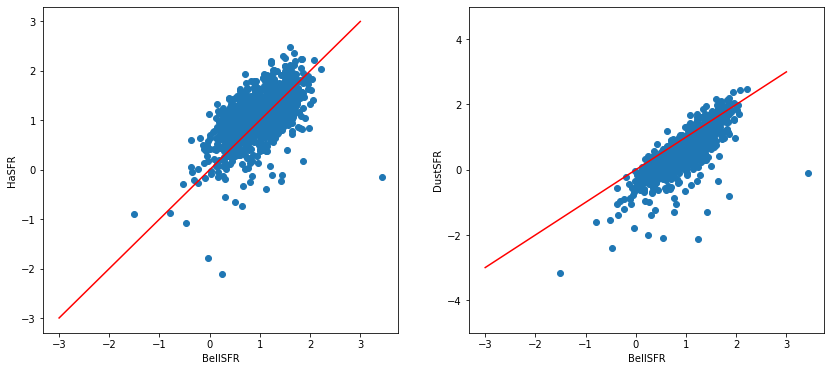

In [152]:
fig, (ax1,ax2)=plt.subplots(1,2, figsize=(14,6))

ax1.scatter(np.log10(sample1['Bell_SFR']),np.log10(sample1['Ha_SFR']))
ax2.scatter(np.log10(sample1['Bell_SFR']),np.log10(sample1['LHa_impr']))

ax1.plot((-3,3), (-3,3), color='red')
ax2.plot((-3,3), (-3,3), color='red')
ax2.set_ylim(-5,5)

ax2.set_xlabel('BellSFR')
ax2.set_ylabel('DustSFR')
ax1.set_xlabel('BellSFR')
ax1.set_ylabel('HaSFR')

(array([-2., -1.,  0.,  1.,  2.,  3.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

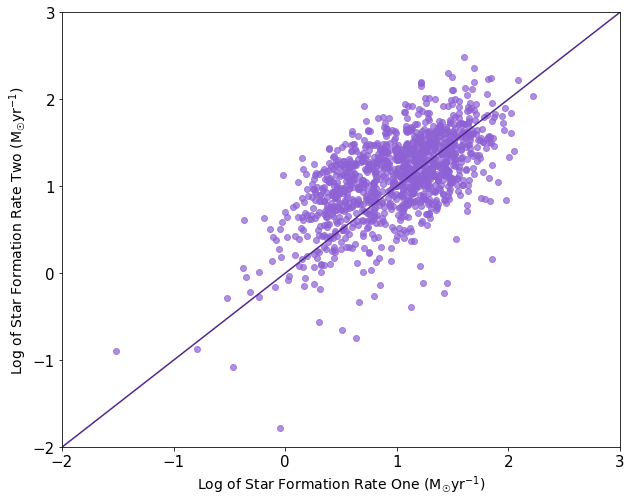

In [101]:
plt.figure(figsize=(10,8))

plt.plot((-2,3), (-2,3), color='#50288d')

plt.scatter(np.log10(sample1['Bell_SFR']),np.log10(sample1['Ha_SFR']), color='#8e61d4', alpha=0.7)

plt.xlim(-2,3)
plt.ylim(-2,3)

plt.xlabel('Log of Star Formation Rate One (M$_☉$yr$^{-1}$)', fontsize=14)
plt.ylabel('Log of Star Formation Rate Two (M$_☉$yr$^{-1}$)', fontsize=14)

plt.xticks(fontsize = 15) 
plt.yticks(fontsize = 15) 

### <span style='background :LightPink' > Scatter Diagram

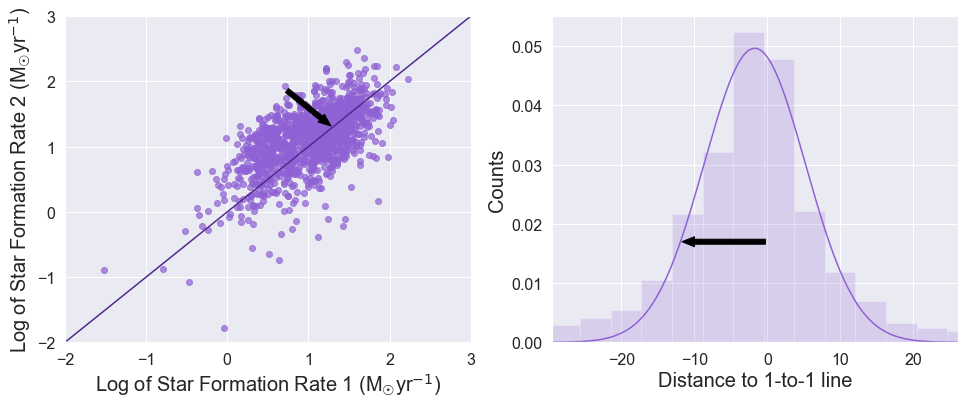

In [196]:
fig, (ax1, ax2)= plt.subplots(1,2, figsize=(16, 6))

ax1.plot((-2,3), (-2,3), color='#50288d')

ax1.scatter(np.log10(sample1['Bell_SFR']),np.log10(sample1['Ha_SFR']), color='#8e61d4', alpha=0.7)

ax1.set_xlim(-2,3)
ax1.set_ylim(-2,3)

ax1.set_xlabel('Log of Star Formation Rate 1 (M$_☉$yr$^{-1}$)', fontsize=20)
ax1.set_ylabel('Log of Star Formation Rate 2 (M$_☉$yr$^{-1}$)', fontsize=20)

#plt.xticks(fontsize = 15) 
#plt.yticks(fontsize = 15) 


arr = mpatches.FancyArrowPatch((0.717505,1.880142),(1.298,1.298), arrowstyle='simple,head_width=.4', mutation_scale=25, color='black')
ax1.add_patch(arr)

ax1.tick_params(axis='both', which='major', labelsize=16)


#______________________________________________________________________________________________________________________

bins=500
     
counts, bins, patches = ax2.hist(dist_df['BellvsHa'].sort_values(), bins = bins, color = '#8e61d4', density = True, alpha=0.2)
        
bins= (bins[:-1] + np.diff(bins) / 2)

param, cov = curve_fit(gaussian, bins, counts, p0=(0,1,10), maxfev=100000)

ax2.plot(dist_df[name].sort_values(), gaussian(dist_df[name].sort_values(), *param), '-', color = '#8e61d4', lw=1.5)

amp_gaus  = param[0] #amplitude 
mean_gaus = param[1] #mean of gaussian dist
std_gau   = param[2] #stdev of the dist

ax2.set_xlabel('Distance to 1-to-1 line', fontsize=20)
ax2.set_ylabel('Counts', fontsize=20)
ax2.set_xlim(mean_gaus-4*std_gau, mean_gaus+4*std_gau )
ax2.tick_params(axis='both', which='major', labelsize=16)
        
arr1 = mpatches.FancyArrowPatch((0,0.017),(-11.99,0.017), arrowstyle='simple,head_width=.4', mutation_scale=25, color='black')
ax2.add_patch(arr1)

(0.0, 300.0)

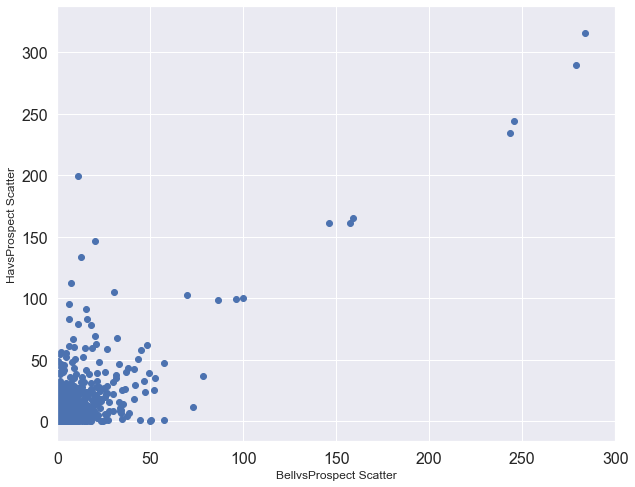

In [199]:
plt.figure(figsize=(10,8))
plt.scatter(np.abs(dist_df['BellvsProspect_Radio']), np.abs(dist_df['HavsProspect_Radio'] ))
plt.xlabel('BellvsProspect Scatter', fontsize=12)
plt.ylabel('HavsProspect Scatter', fontsize=12)
plt.xlim(0,300)

# AGNS 